## Setup, dane i dobor filtrow


In [1]:
from funkcje_IMU import *
from funkcje_GT import *
from funkcje_IMU_GT import *
from funkcje_camera import *
from IMUFilter import *
from SensorFusionEngine import *


# Konfiguracja danych


In [2]:
data_files = {
    'horizontal_line_1' : {
        'imu': 'IMU/dataLog00075.TXT',
        'gt': 'dobot/horizontal_line_1774951923.csv',
        'cam': 'POMIARY/horizontal_10x_5sp__x/optical_flow.csv'
    },
    'horizontal_line_2' : {
        'imu': 'IMU/dataLog00077.TXT',
        'gt': 'dobot/horizontal_line_1774952687.csv',
        'cam': 'POMIARY/horizontal_10x_8sp__x/optical_flow.csv'
    },
    'vertical_line_1' : {
        'imu': 'IMU/dataLog00079.TXT',
        'gt': 'dobot/vertical_line_1774953045.csv',
        'cam': 'POMIARY/vertical_10x_5sp__y/optical_flow.csv'
    },
    'vertical_line_2' : {
        'imu': 'IMU/dataLog00081.TXT',
        'gt': 'dobot/vertical_line_1774953360.csv',
        'cam': 'POMIARY/vertical_10x_8sp__y/optical_flow.csv'
    },
    'square_1' : {
        'imu': 'IMU/dataLog00083.TXT',
        'gt': 'dobot/square_1774953674.csv',
        'cam': 'POMIARY/square_4x_5sp__x,y/optical_flow.csv'
    },
    'square_2' : {
        'imu': 'IMU/dataLog00085.TXT',
        'gt': 'dobot/square_1774953882.csv',
        'cam': 'POMIARY/square_4x_8sp__x,y/optical_flow.csv'
    },
    'triangle_1' : {
        'imu': 'IMU/dataLog00087.TXT',
        'gt': 'dobot/triangle_1774954203.csv',
        'cam': 'POMIARY/triangle_4x_5sp__x,y/optical_flow.csv'
    },
    'triangle_2' : {
        'imu': 'IMU/dataLog00089.TXT',
        'gt': 'dobot/triangle_1774954436.csv',
        'cam': 'POMIARY/triangle_4x_8sp__x,y/optical_flow.csv'
    },
    'cross_1' : {
        'imu': 'IMU/dataLog00091.TXT',
        'gt': 'dobot/cross_1774954750.csv',
        'cam': 'POMIARY/cross_4x_5sp__x,y/optical_flow.csv'
    },
    'cross_2' : {
        'imu': 'IMU/dataLog00093.TXT',
        'gt': 'dobot/cross_1774954990.csv',
        'cam': 'POMIARY/cross_4x_8sp__x,y/optical_flow.csv'
    },
    'rotation_1' : {
        'imu': 'IMU/dataLog00095.TXT',
        'gt': 'dobot/rotation_1774955556.csv',
        'cam': 'POMIARY/roration_4x_5sp__pitch/optical_flow.csv'
    },
    'rotation_2' : {
        'imu': 'IMU/dataLog00097.TXT',
        'gt': 'dobot/rotation_1774955732.csv',
        'cam': 'POMIARY/roration_4x_8sp__pitch/optical_flow.csv'
    },
    'rotation_h_line_1' : {
        'imu': 'IMU/dataLog00099.TXT',
        'gt': 'dobot/rotation_1774955850.csv',
        'cam': 'POMIARY/roration_h_line_5x_5sp__x,pitch/optical_flow.csv'
    },
    'rotation_h_line_2' : {
        'imu': 'IMU/dataLog00101.TXT',
        'gt': 'dobot/rotation_1774955920.csv',
        'cam': 'POMIARY/roration_h_line_5x_8sp__x,pitch/optical_flow.csv'
    }
}


In [3]:
LOOP_CLOSURE = False
selected_dataset = 'horizontal_line_1'
file_path = 'Data/'


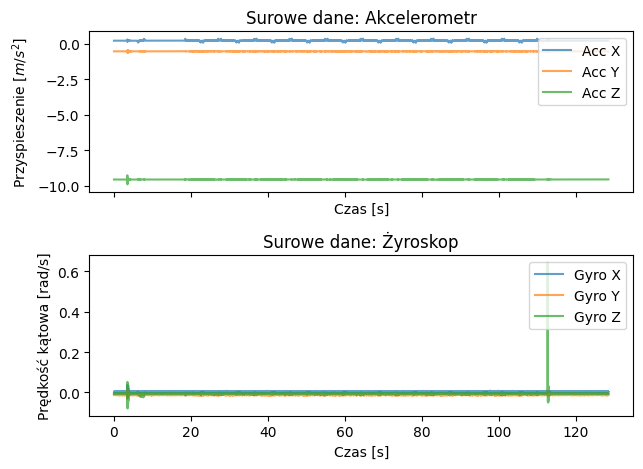

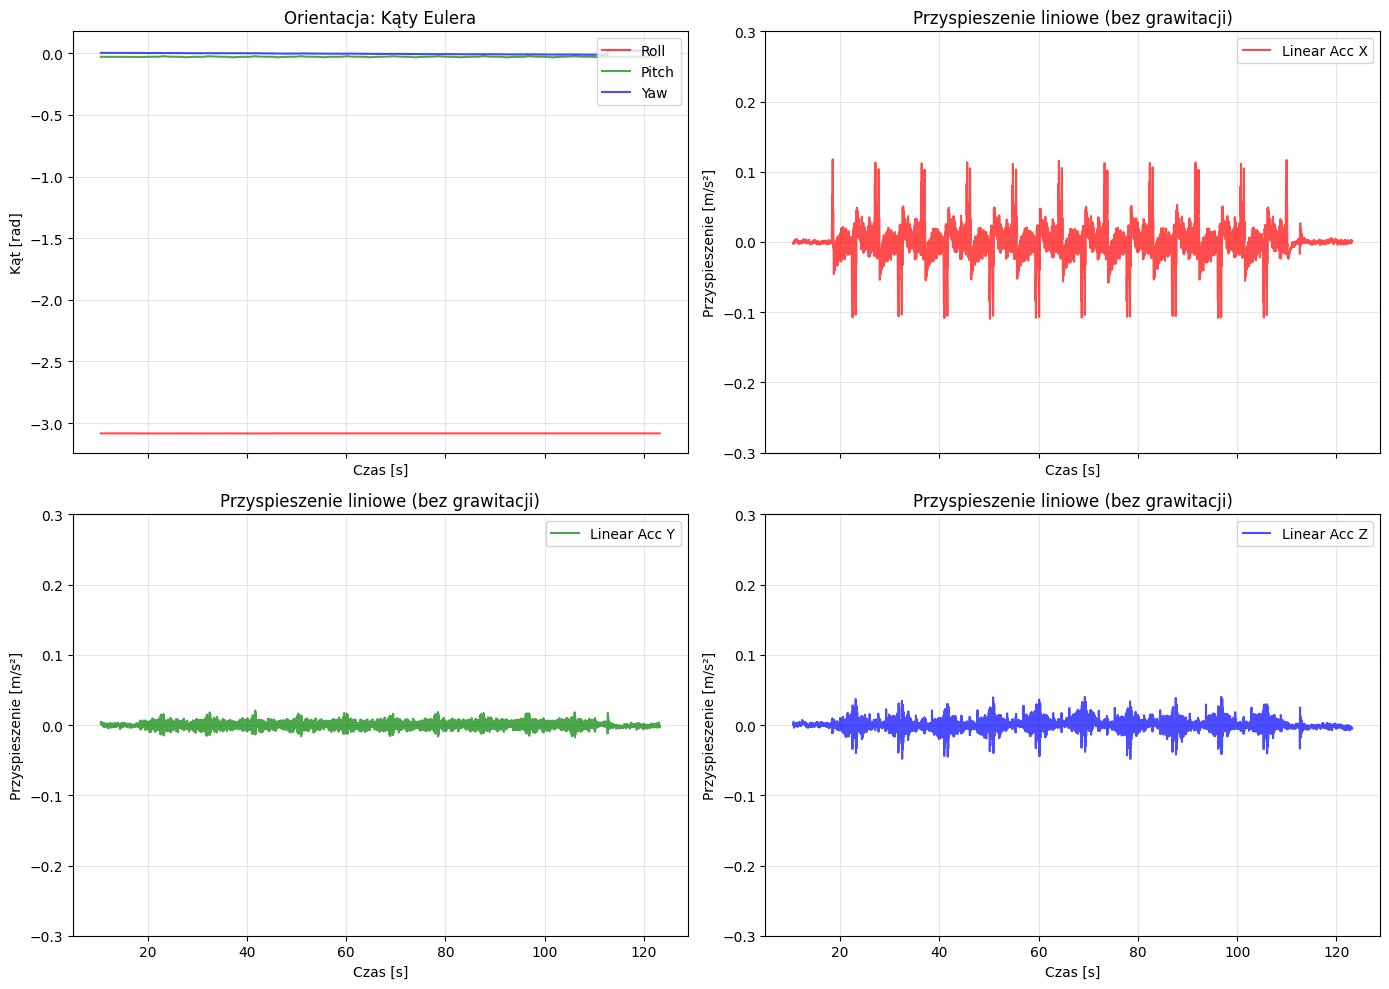

In [4]:
# IMU
df_imu = load_IMU_data(file_path + data_files[selected_dataset]['imu'])
df_imu = compute_orientation_and_global_acc(df_imu)
plot_raw_IMU_data(df_imu)
df_imu = trim_IMU_data(df_imu, trim_start=1000, trim_end=500)
df_imu = resample_IMU_data(df_imu, 100.0)
# df_imu = remove_trend(df_imu)
# df_imu = remove_moving_average_trend(df_imu)
df_imu = remove_average_trend(df_imu)
plot_acceleration_and_orientation(df_imu)

# Ground Truth
df_gt = load_ground_truth(file_path + data_files[selected_dataset]['gt'])
df_gt = trim_ground_truth(df_gt, trim_start=200, trim_end=200)
df_gt = normalize_ground_truth(df_gt)
df_gt = resample_ground_truth(df_gt, target_fps=100.0)

# Camera
df_camera = load_camera_data(file_path + data_files[selected_dataset]['cam'])


In [5]:
df_gt.describe()

,timestamp,X,Y,Z,R
count,10243.000000,10243.000000,10243.0,1.024300e+04,10243.0
mean,53.182181,0.045071,0.0,1.156217e-10,0.0
std,29.570437,0.034224,0.0,2.272758e-09,0.0
min,1.972181,0.000000,0.0,-8.000000e-09,0.0
25%,27.577181,0.011675,0.0,0.000000e+00,0.0
50%,53.182181,0.043679,0.0,0.000000e+00,0.0
75%,78.787181,0.075692,0.0,0.000000e+00,0.0
max,104.392181,0.100000,0.0,8.000000e-09,0.0


=== Synchronizacja przez korelację krzyżową ===
Obliczone przesunięcie: -265 próbek


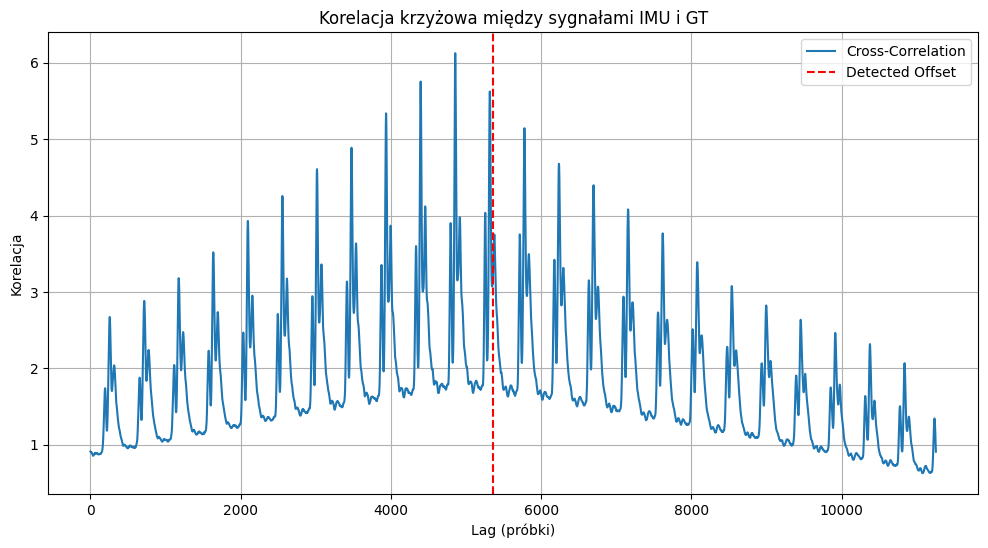

In [6]:
df_gt = calculate_derivatives(df_gt)
df_sync = synchronize_by_cross_correlation(df_imu, df_gt, plot_data=True)


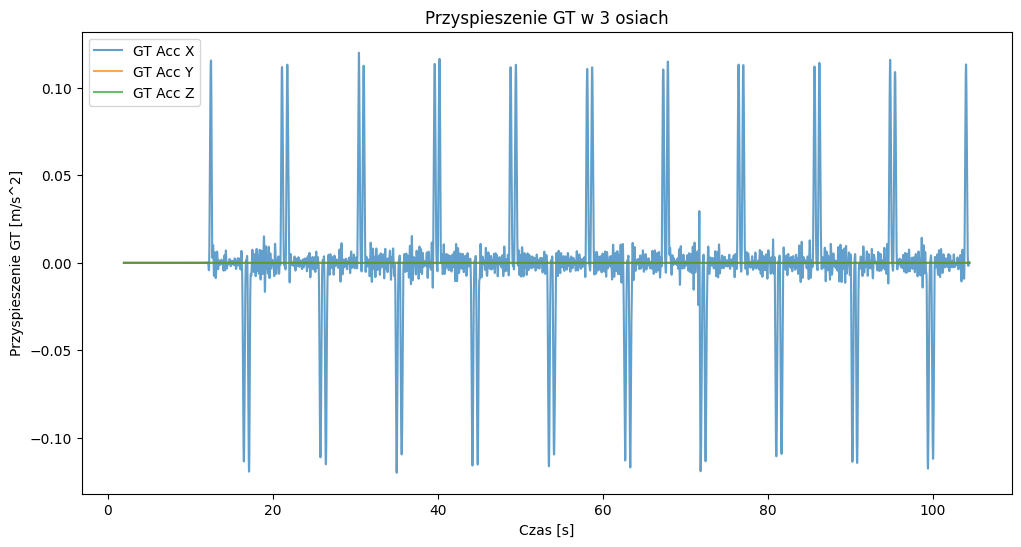

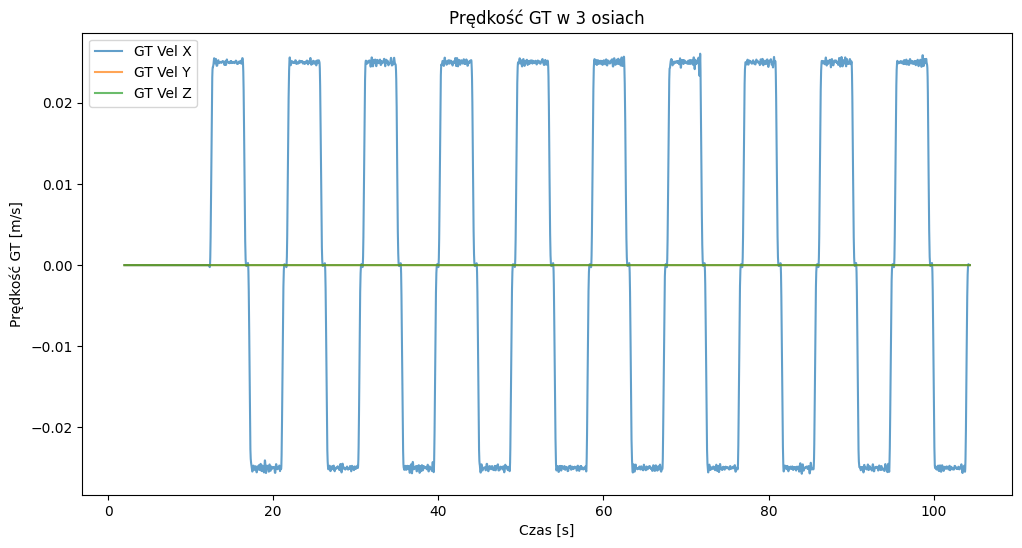

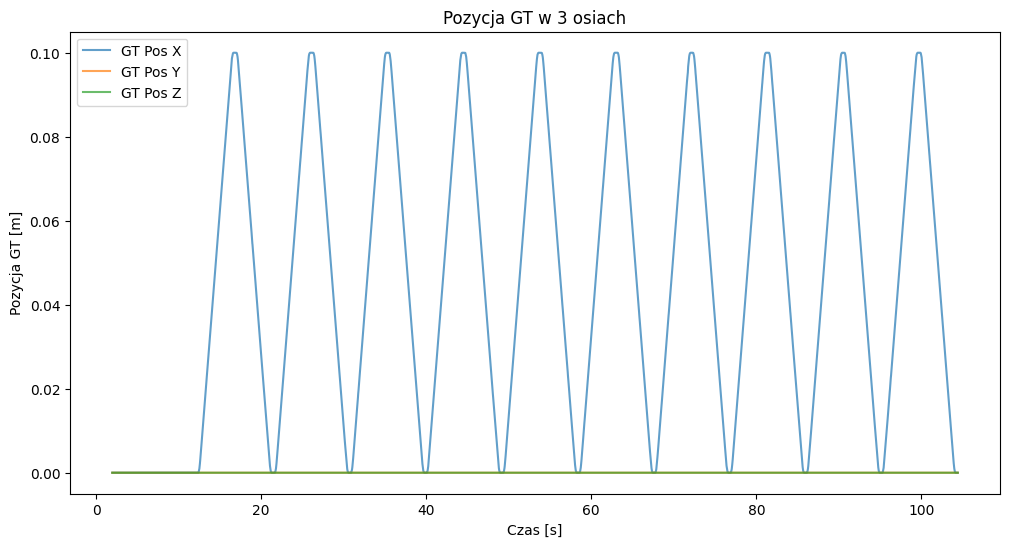

In [7]:
plot_ground_truth(df_gt)

In [8]:
print(f"Liczba próbek IMU: {len(df_imu)}")
print(f"Liczba próbek GT: {len(df_gt)}")
print(f"Liczba próbek po synchronizacji: {len(df_sync)}")

Liczba próbek IMU: 11255
Liczba próbek GT: 10243
Liczba próbek po synchronizacji: 9978



TESTOWANIE PARAMETROW FILTROW

1. BUTTERWORTH - test cutoff and order:

   Najlepszy wynik Butterwortha:
   cutoff=3.8 Hz, order=5: RMSE=10.086751


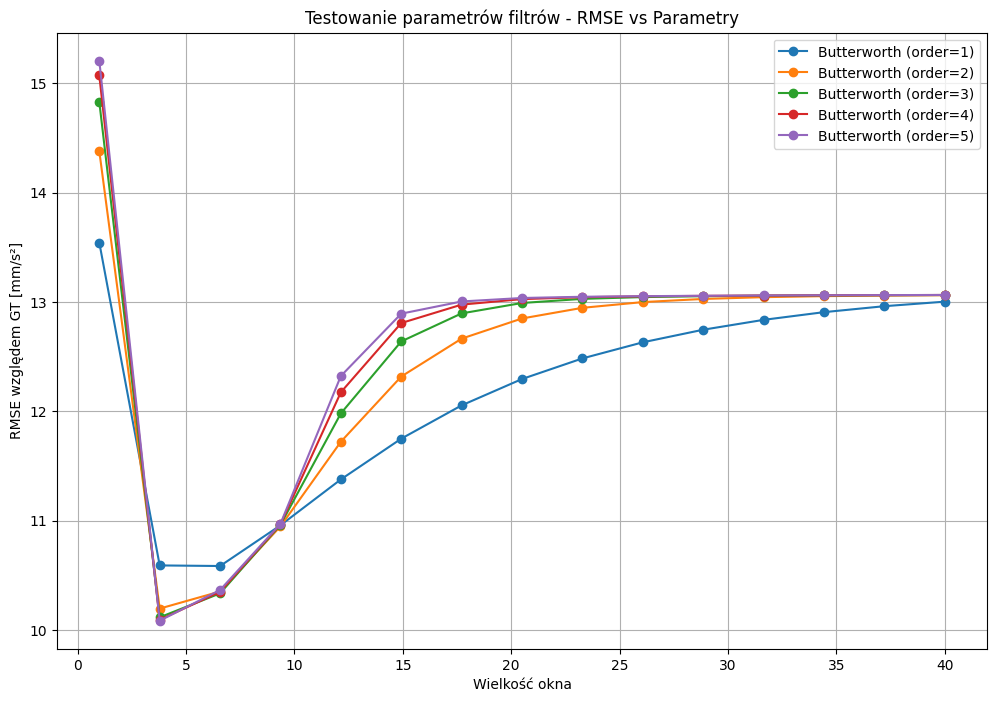


2. SAVITZKY-GOLAY - test window lengths and polyorder:

   Najlepszy wynik Savitzky-Golay:
   window=45, polyorder=5: RMSE=10.142490


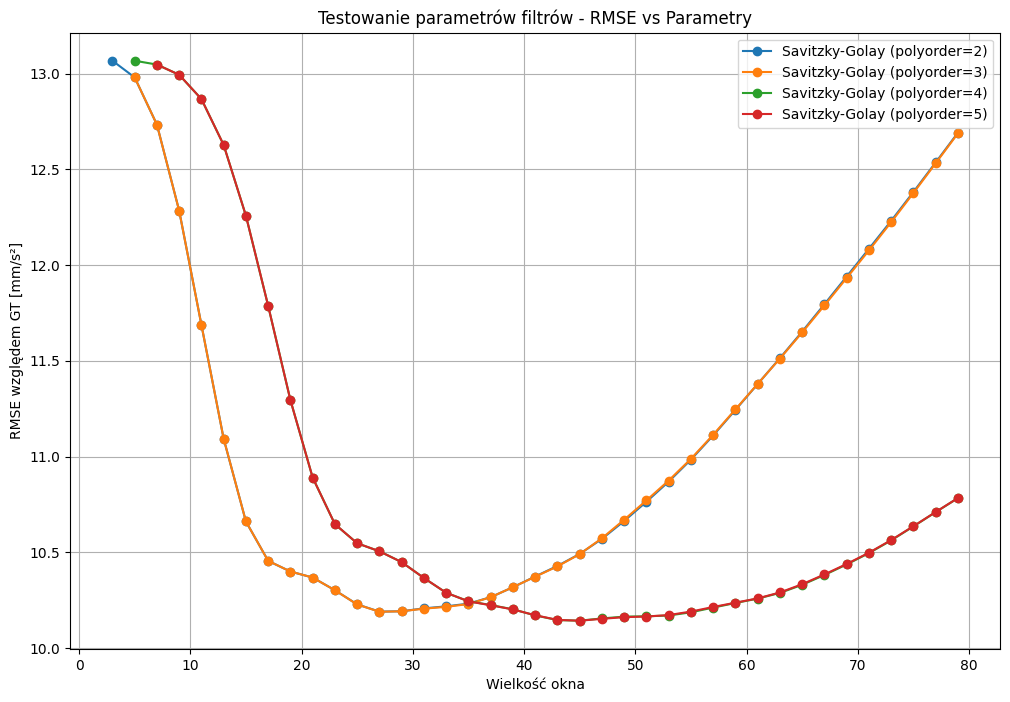


3. MEDIAN - test window sizes:

   Najlepszy wynik mediany:
   size=11: RMSE=10.711938


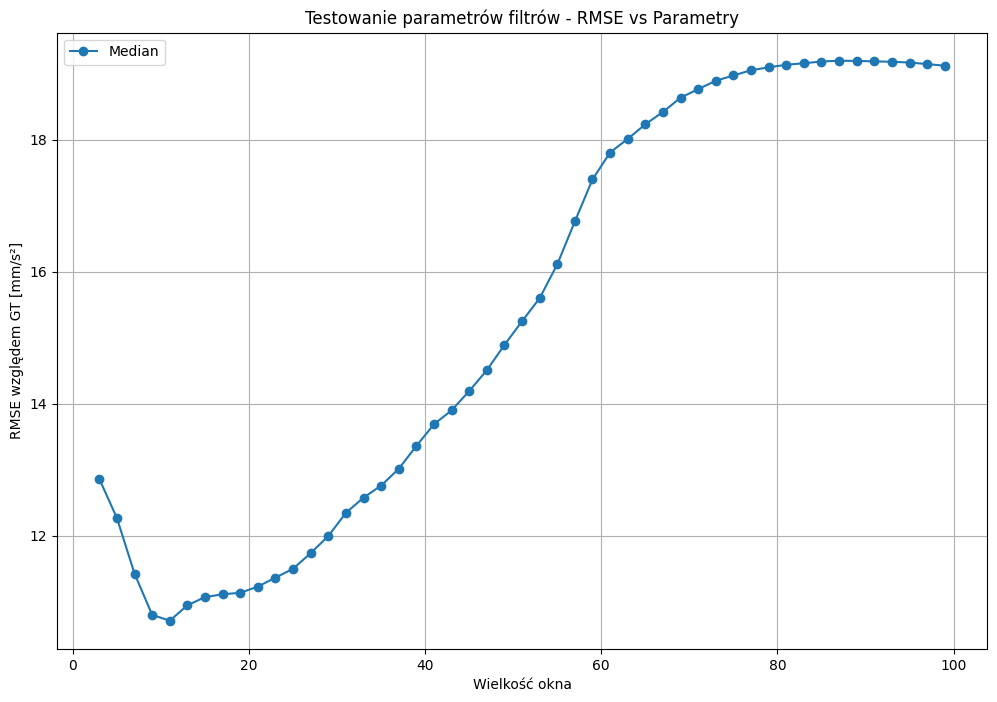


4. KALMAN - test Q and R values:

   Najlepszy wynik Kalmana:
   Q=3.7e-03, R=4.4e-02: RMSE=11.173357


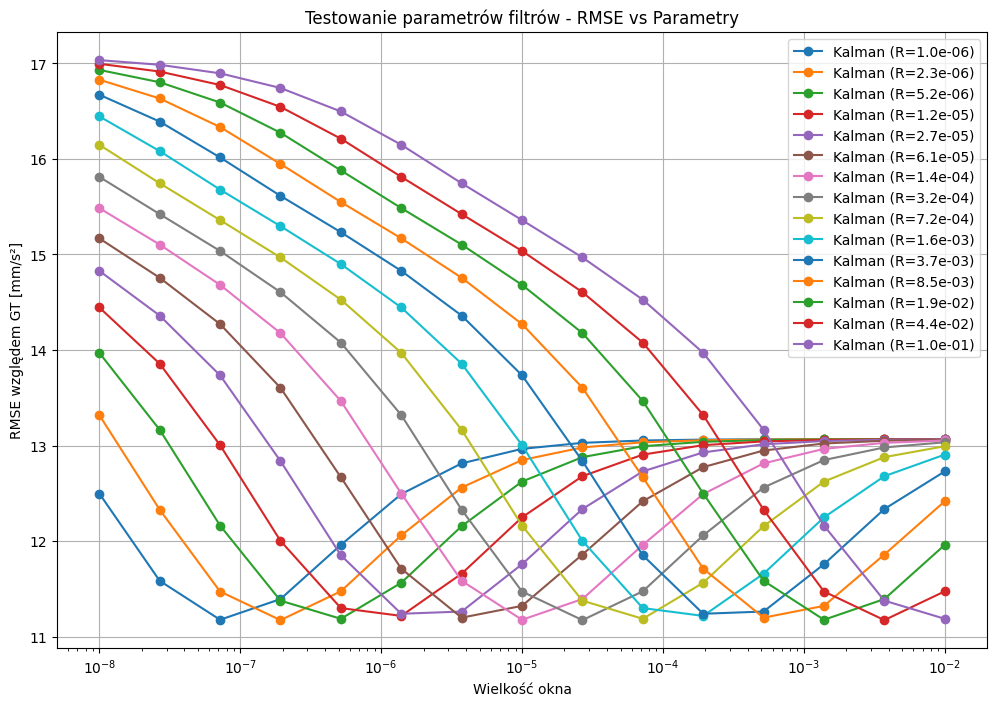


5. MOVING AVERAGE - test window sizes:

   Najlepszy wynik średniej ruchomej:
   window=11: RMSE=10.337355


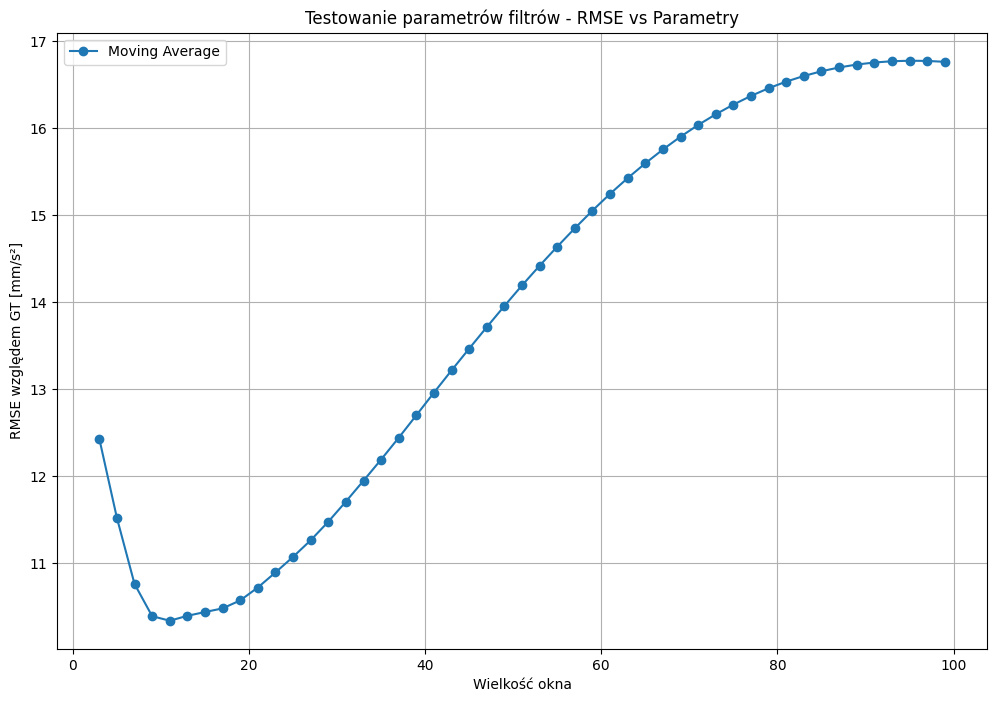


6. WIENER - test window sizes:

   Najlepszy wynik Wienera:
   window=17: RMSE=10.872297


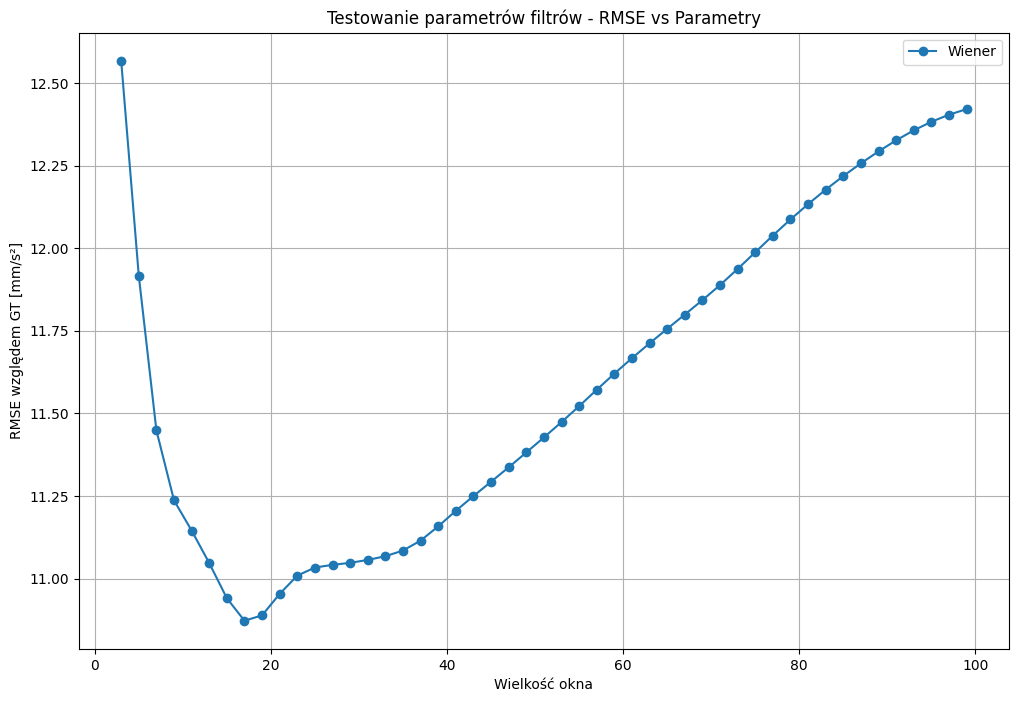

{'butterworth': {'cutoff': 3.7857142857142856, 'order': 5},
 'savgol': {'window_length': 45, 'polyorder': 5},
 'median': {'size': 11},
 'kalman': {'Q': 0.003727593720314938, 'R': 0.04393970560760795},
 'moving_avg': {'window': 11},
 'wiener': {'window': 17}}

In [9]:
best_params = test_filter_parameters(df_sync)
best_params


In [10]:
IMU_filter = IMUFilter(fs=100.0)
df_with_filters = IMU_filter.add_filtered_columns(df_sync, best_params)

results = calculate_rmse_vs_gt(df_with_filters)
raw_rmse = dict(results).get('Raw (gl_acc)')

for method_name, rmse in results:
    if raw_rmse and method_name != 'Raw (gl_acc)':
        gain = ((raw_rmse - rmse) / raw_rmse) * 100
        print(f"Metoda: {method_name:20} | RMSE: {rmse:.4f} | Gain vs Raw: {gain:.2f}%")
    else:
        print(f"Metoda: {method_name:20} | RMSE: {rmse:.4f}")


Metoda: butterworth          | RMSE: 0.0101 | Gain vs Raw: 22.81%
Metoda: savgol               | RMSE: 0.0101 | Gain vs Raw: 22.39%
Metoda: moving_avg           | RMSE: 0.0103 | Gain vs Raw: 20.90%
Metoda: median               | RMSE: 0.0107 | Gain vs Raw: 18.03%
Metoda: wiener               | RMSE: 0.0109 | Gain vs Raw: 16.80%
Metoda: kalman               | RMSE: 0.0112 | Gain vs Raw: 14.50%
Metoda: Raw (gl_acc)         | RMSE: 0.0131
Metoda: original             | RMSE: 0.0131 | Gain vs Raw: 0.00%


Wybrana metoda do dalszego pipeline'u: butterworth


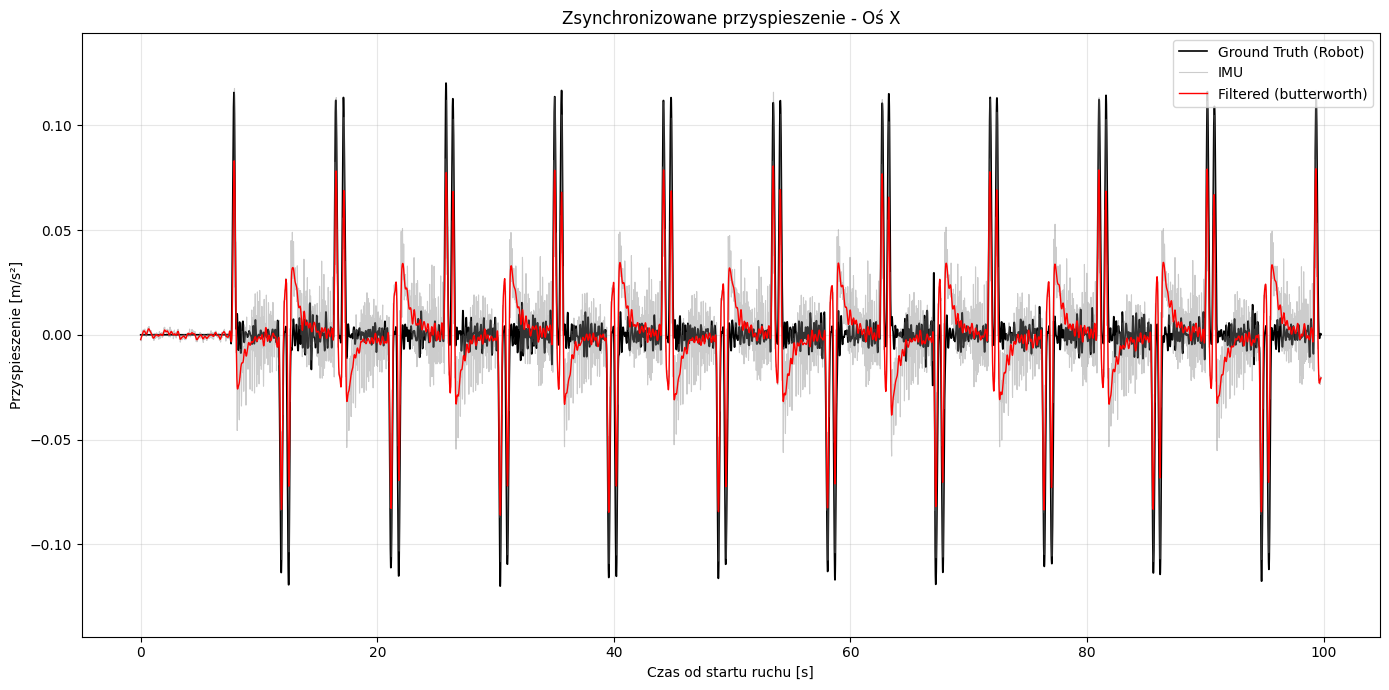

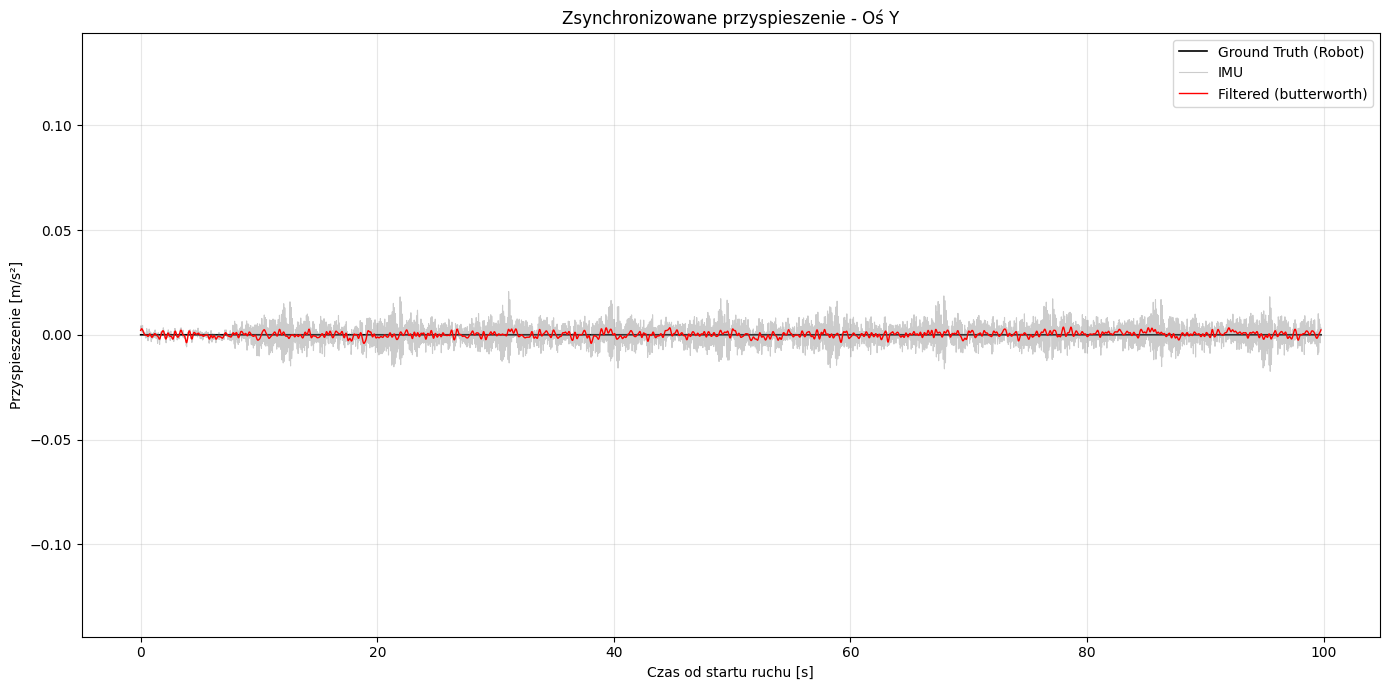

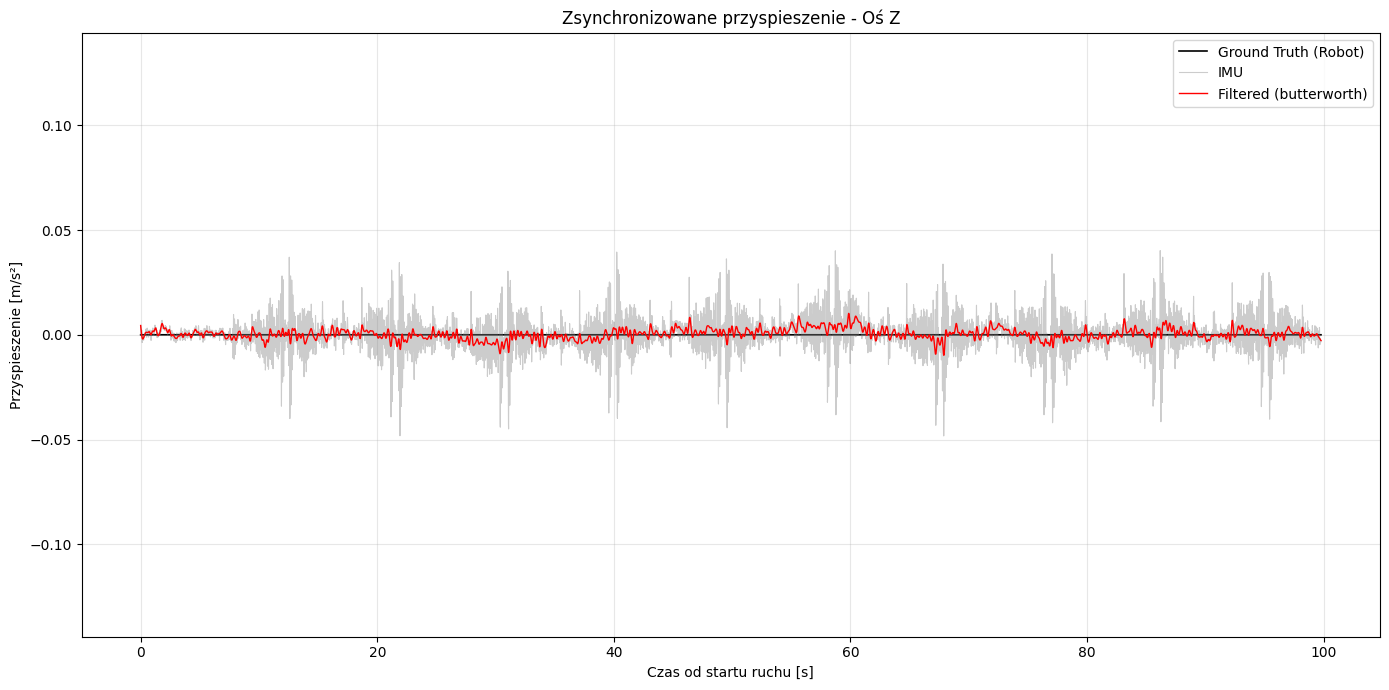

In [11]:
best_method_name = results[0][0]
method = 'gl' if best_method_name == 'Raw (gl_acc)' else best_method_name

print(f"Wybrana metoda do dalszego pipeline'u: {method}")
plot_synchronized_results(df_with_filters, filter_name=method)


In [15]:
df_results = calculate_integrals(df_with_filters, method=method, high_pass_cutoff=0.09, use_detrend_vel=False, use_detrend_pos=False, use_loop_closure=LOOP_CLOSURE, apply_hp_filter=False)

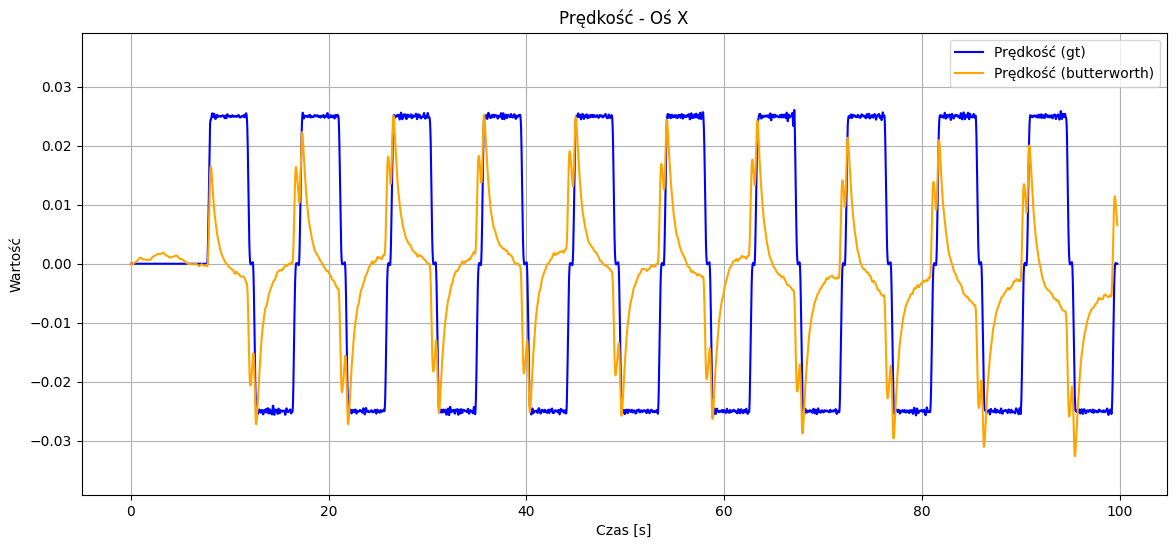

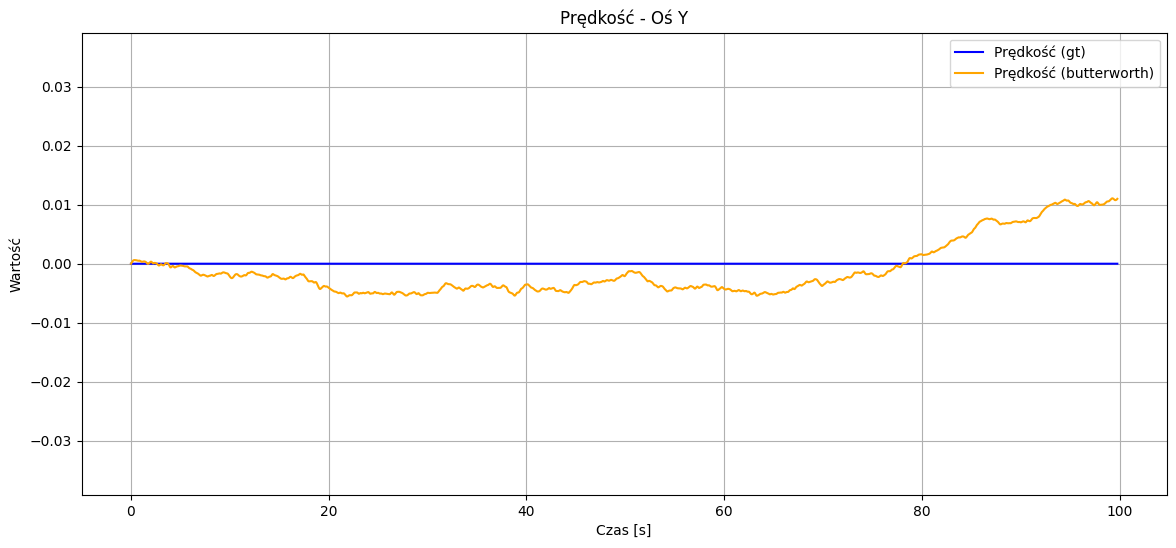

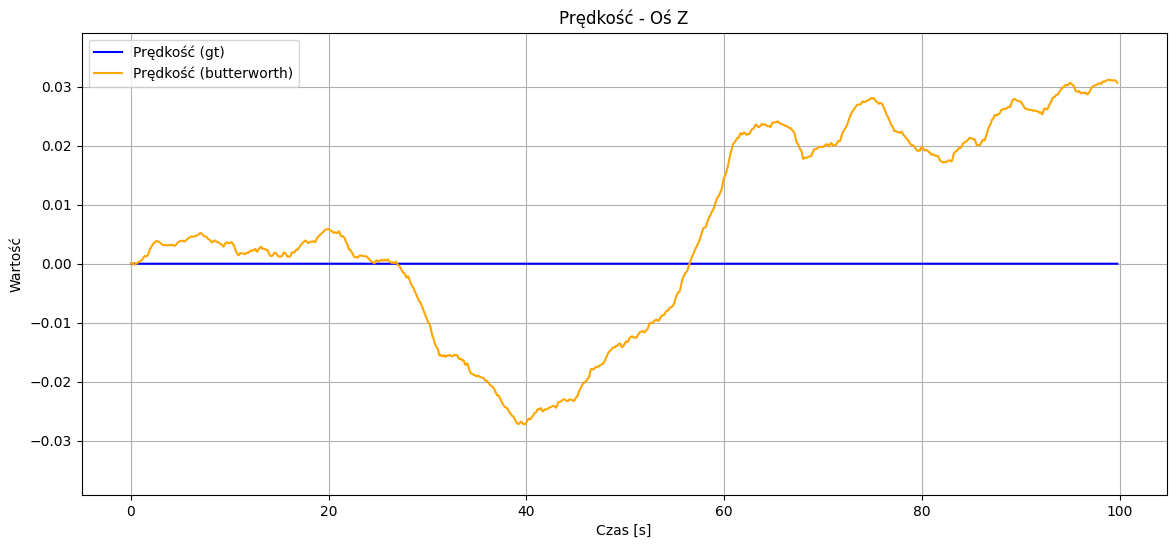

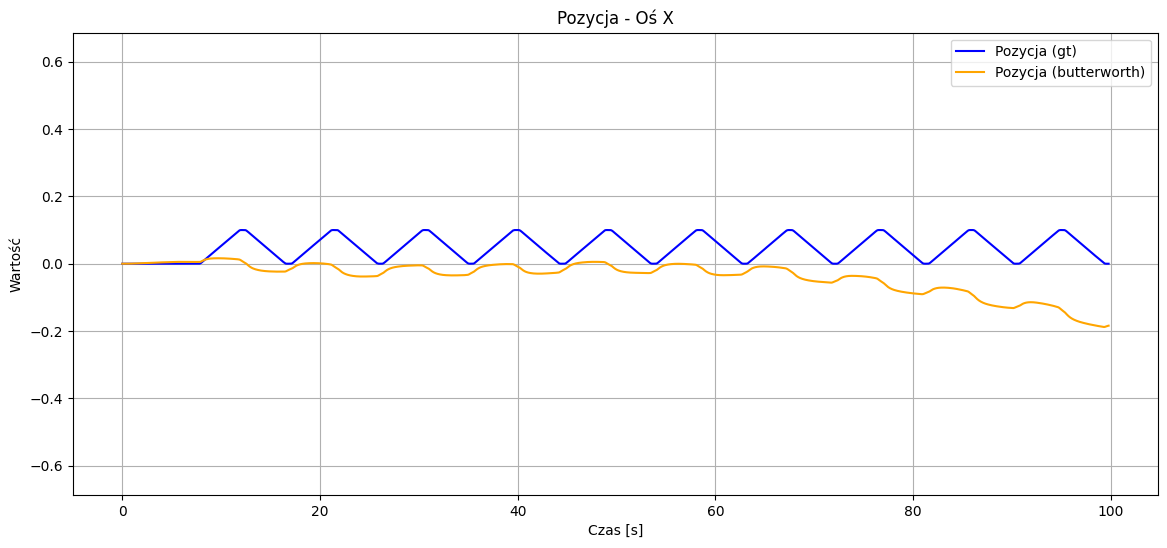

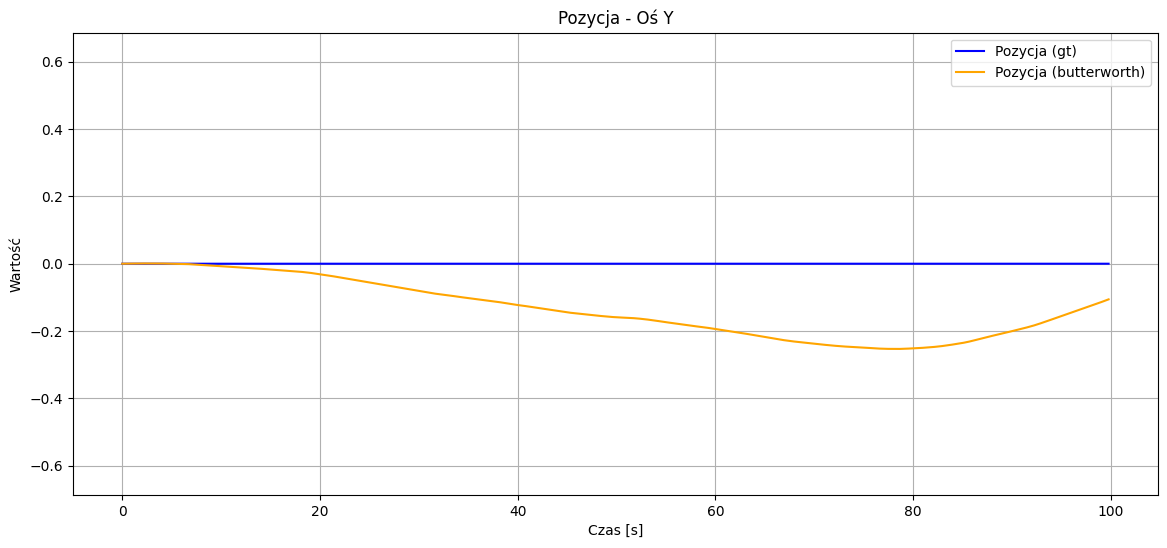

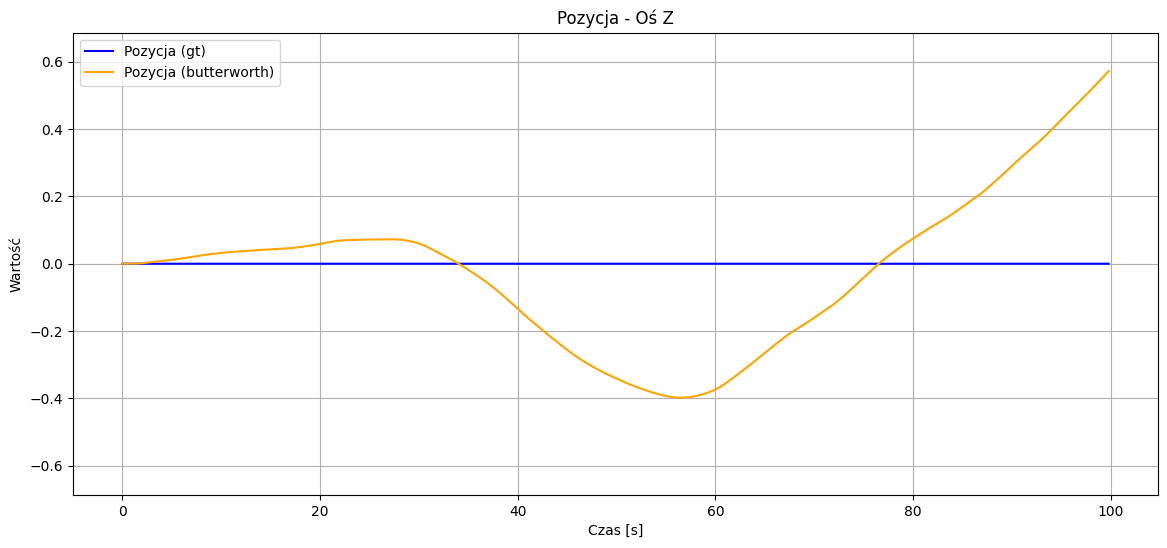

In [16]:
plot_velocity_and_position(df_results, method=method)

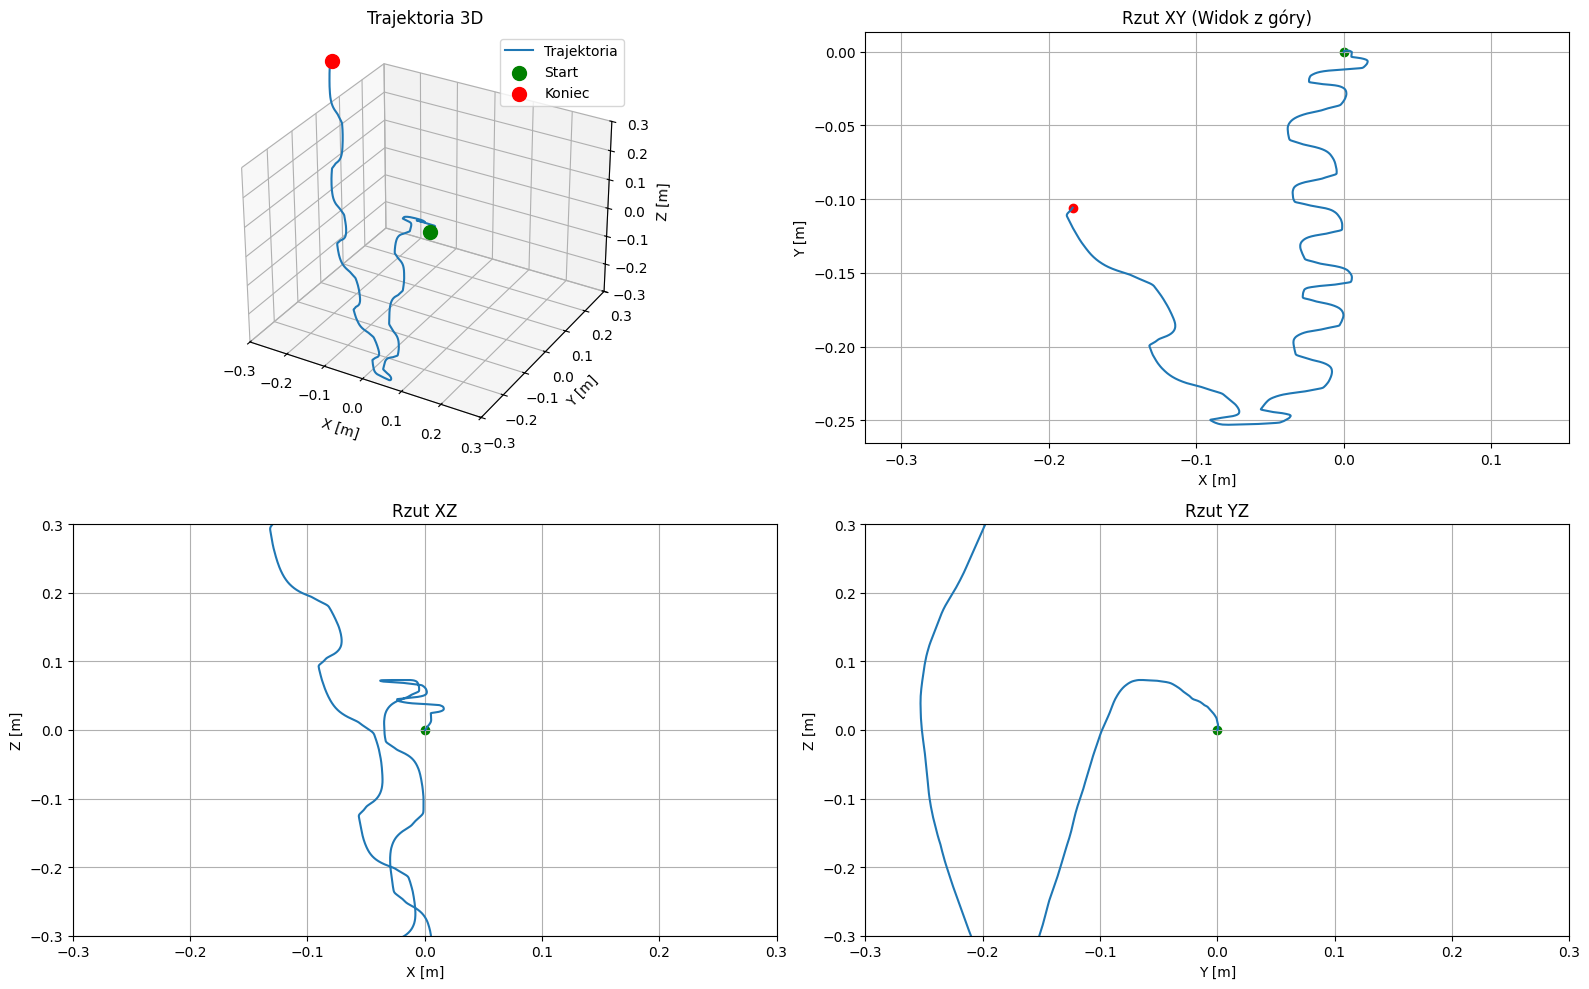

In [17]:
visualize_trajectory(df_results, method=method)

# Dane z kamery

In [ ]:
df_camera = resample_camera_data(df_camera, target_fps=100.0, current_fps=30.0)

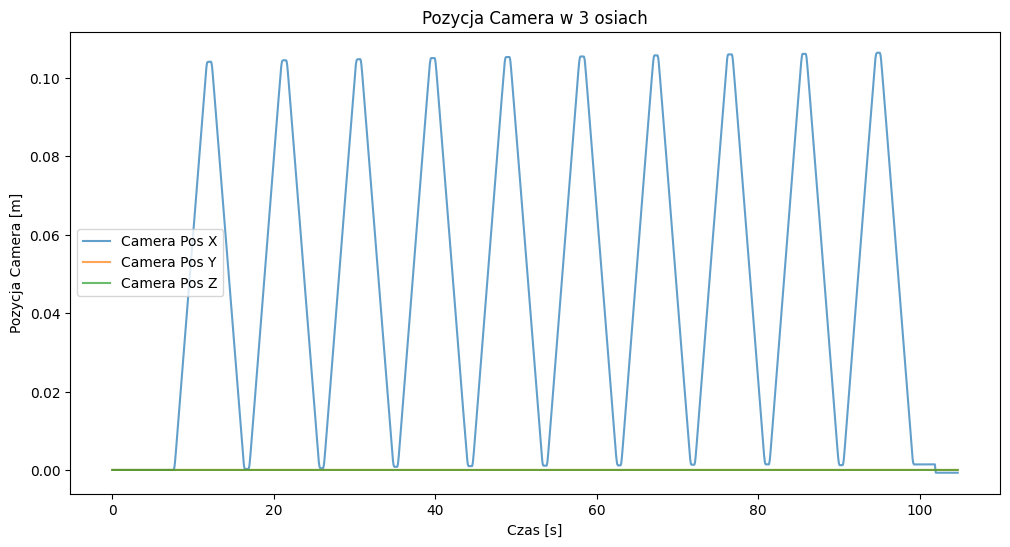

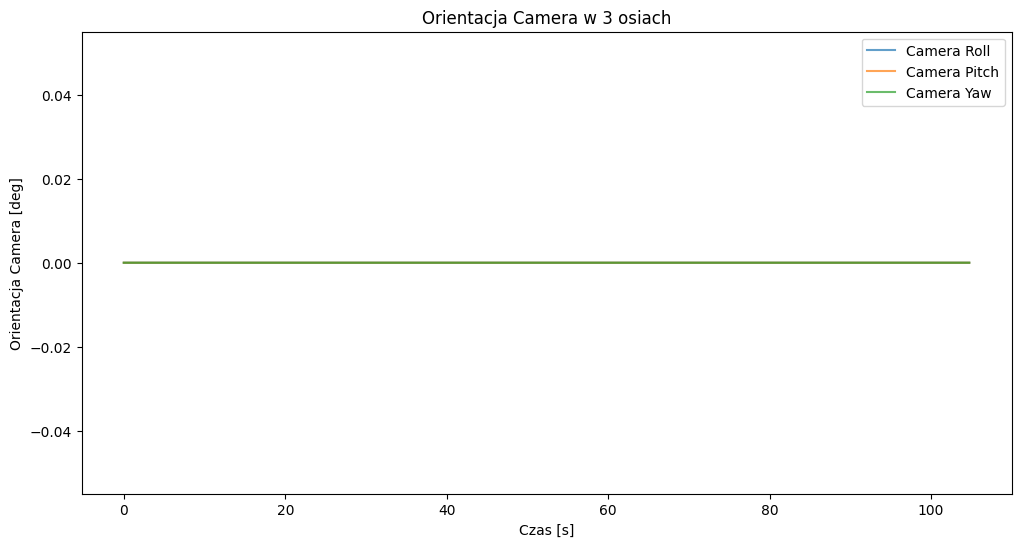

In [21]:
plot_camera_data(df_camera)

=== Synchronizacja przez korelację krzyżową ===
Obliczone przesunięcie: 19 próbek


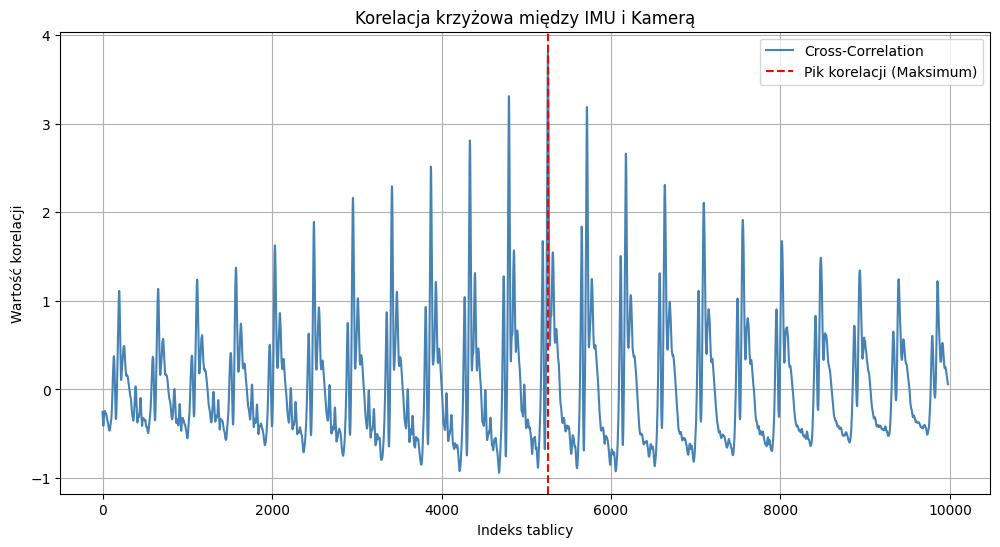

In [22]:
df_sync_cam = synchronize_imu_camera(df_results, df_camera, imu_prefix=method, plot_data=True)

In [23]:
apply_camera_confidence(df_sync_cam, cam_prefix='cam', noise_type=True, conf_intervals=[(26.0, 27.0)])
# apply_camera_confidence(df_sync_cam, cam_prefix='cam', noise_type=True, conf_intervals=[(26.0, 27.0), (46, 47.0)])
# apply_camera_confidence(df_sync_cam, cam_prefix='cam', noise_type=True, conf_intervals=[(26.0, 27.0), (46, 47.0), (66.0, 67.0)])

,ts,gl_acc_x,gl_acc_y,gl_acc_z,roll,pitch,yaw,gt_acc_x,gt_vel_x,gt_pos_x,...,butterworth_vel_z,butterworth_pos_z,cam_pos_x,cam_pos_y,cam_pos_z,cam_roll,cam_pitch,cam_yaw,cam_timestamp,cam_conf
0,10.78717,0.002051,0.002115,-0.002424,-3.084024,-0.028637,0.003390,0.000000,0.000000e+00,0.0,...,0.000013,0.000021,-0.000000,0.0,-0.0,0.0,0.0,0.0,0.00,1.0
1,10.79717,0.001874,0.001085,-0.001455,-3.084023,-0.028653,0.003405,0.000000,0.000000e+00,0.0,...,-0.000006,0.000021,0.000000,0.0,0.0,0.0,0.0,0.0,0.01,1.0
2,10.80717,0.001868,0.001868,-0.001277,-3.084018,-0.028653,0.003418,0.000000,0.000000e+00,0.0,...,-0.000026,0.000021,0.000000,0.0,0.0,0.0,0.0,0.0,0.02,1.0
3,10.81717,-0.000097,0.001092,-0.000475,-3.084017,-0.028660,0.003399,0.000000,0.000000e+00,0.0,...,-0.000044,0.000021,0.000000,0.0,0.0,0.0,0.0,0.0,0.03,1.0
4,10.82717,0.000256,0.000705,-0.000222,-3.084005,-0.028661,0.003411,0.000000,0.000000e+00,0.0,...,-0.000061,0.000020,0.000000,0.0,0.0,0.0,0.0,0.0,0.04,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9954,110.32717,-0.021144,-0.001084,-0.002862,-3.084149,-0.031255,-0.012200,0.000568,-4.642886e-06,0.0,...,0.030765,0.570193,0.001408,0.0,0.0,0.0,0.0,0.0,99.54,1.0
9955,110.33717,-0.020523,0.002583,-0.002635,-3.084138,-0.031217,-0.012193,0.000568,-2.755544e-06,0.0,...,0.030740,0.570500,0.001408,0.0,0.0,0.0,0.0,0.0,99.55,1.0
9956,110.34717,-0.020074,0.003357,-0.003505,-3.084139,-0.031174,-0.012203,0.000527,-2.324108e-07,0.0,...,0.030715,0.570807,0.001408,0.0,0.0,0.0,0.0,0.0,99.56,1.0
9957,110.35717,-0.021221,0.003299,-0.002944,-3.084135,-0.031114,-0.012219,0.000066,2.853690e-06,0.0,...,0.030688,0.571114,0.001408,0.0,0.0,0.0,0.0,0.0,99.57,1.0


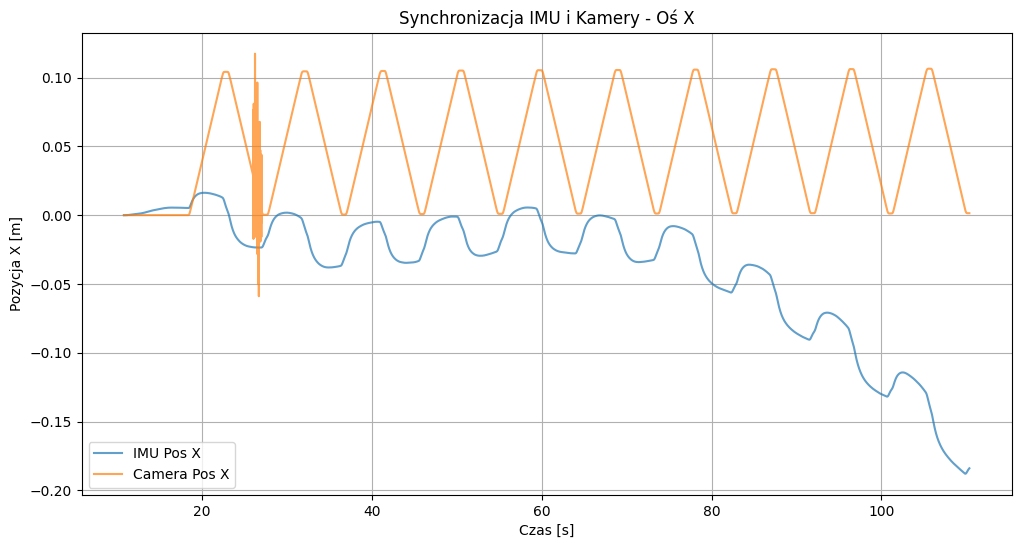

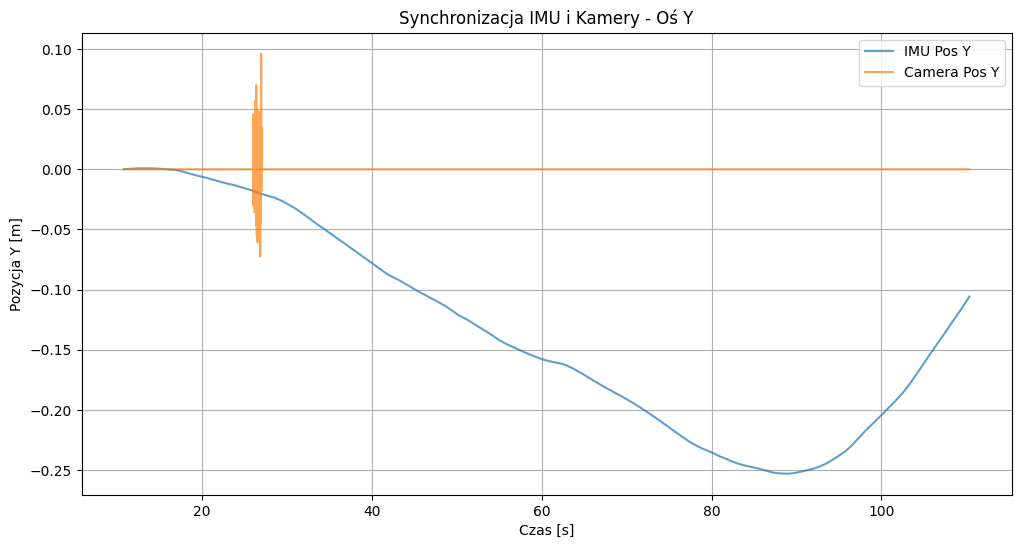

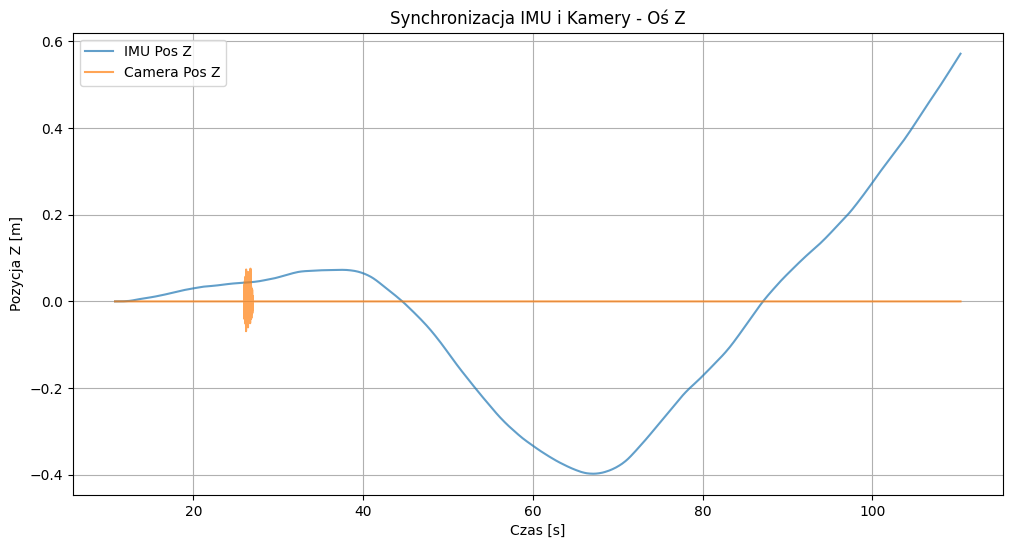

In [24]:
plot_sync_IMU_camera_data(df_sync_cam, imu_prefix=method, cam_prefix='cam')

In [25]:
df_sync_cam.columns

Index(['ts', 'gl_acc_x', 'gl_acc_y', 'gl_acc_z', 'roll', 'pitch', 'yaw',
       'gt_acc_x', 'gt_vel_x', 'gt_pos_x', 'gt_acc_y', 'gt_vel_y', 'gt_pos_y',
       'gt_acc_z', 'gt_vel_z', 'gt_pos_z', 'original_acc_x',
       'butterworth_acc_x', 'savgol_acc_x', 'median_acc_x', 'kalman_acc_x',
       'moving_avg_acc_x', 'wiener_acc_x', 'original_acc_y',
       'butterworth_acc_y', 'savgol_acc_y', 'median_acc_y', 'kalman_acc_y',
       'moving_avg_acc_y', 'wiener_acc_y', 'original_acc_z',
       'butterworth_acc_z', 'savgol_acc_z', 'median_acc_z', 'kalman_acc_z',
       'moving_avg_acc_z', 'wiener_acc_z', 'butterworth_vel_x',
       'butterworth_pos_x', 'butterworth_vel_y', 'butterworth_pos_y',
       'butterworth_vel_z', 'butterworth_pos_z', 'cam_pos_x', 'cam_pos_y',
       'cam_pos_z', 'cam_roll', 'cam_pitch', 'cam_yaw', 'cam_timestamp',
       'cam_conf'],
      dtype='object')

In [26]:
# 2. Inicjalizacja klasy
fusion = SensorFusionEngine(df_sync_cam, imu_prefix=method)

# 3. Wybór metody i parametrów
# df_final = fusion.approach_weighted_average(cam_trust=0.8, loop_closure=LOOP_CLOSURE)
# df_final = fusion.approach_complementary_adaptive_filter(use_confidence=False, alpha=0.9, loop_closure=LOOP_CLOSURE)
# df_final = fusion.approach_complementary_adaptive_filter(use_confidence=True, alpha=0.9, loop_closure=LOOP_CLOSURE)
# df_final = fusion.approach_error_drift_compensation(smoothing_window=205, loop_closure=LOOP_CLOSURE)
df_final = fusion.approach_kalman_adaptive_filter(use_confidence=False, loop_closure=LOOP_CLOSURE)
# df_final = fusion.approach_wiener_filter()

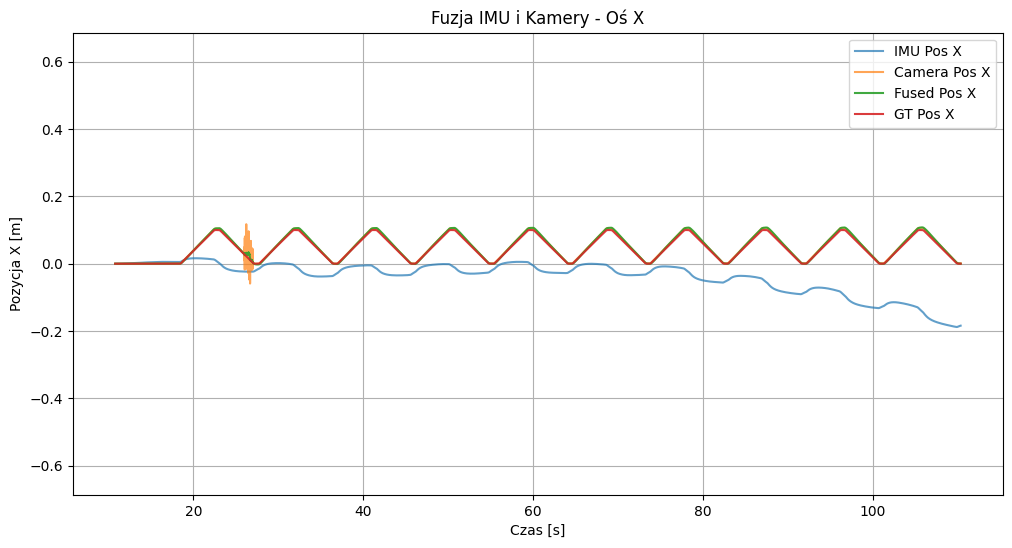

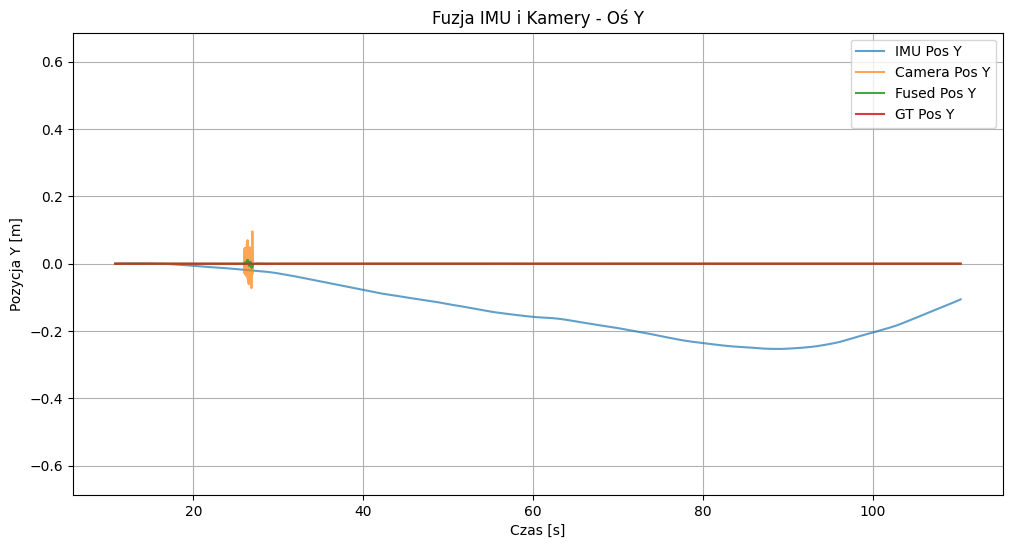

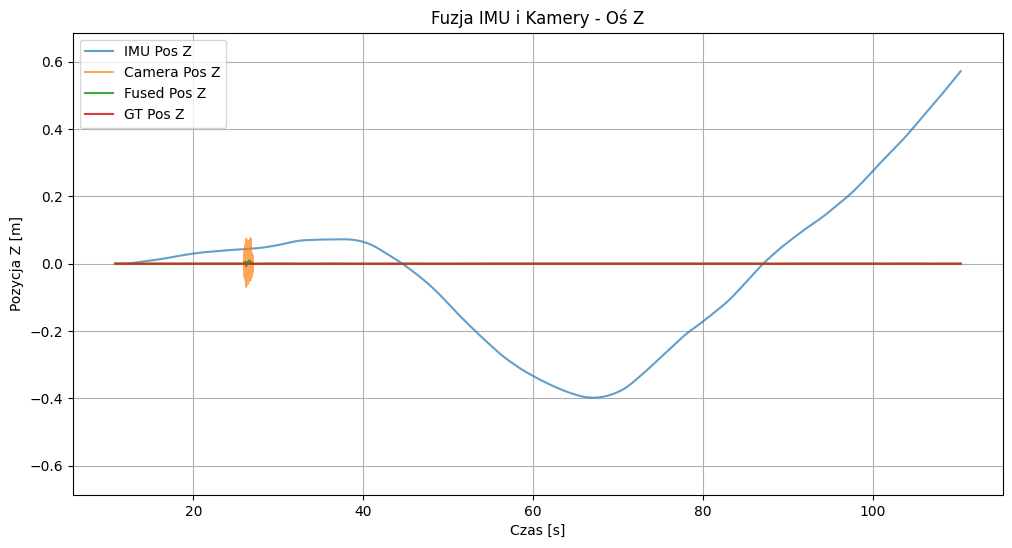

In [27]:
plot_IMU_camera_fusion_results(df_final, imu_prefix=method, cam_prefix='cam', fused_prefix='fused')

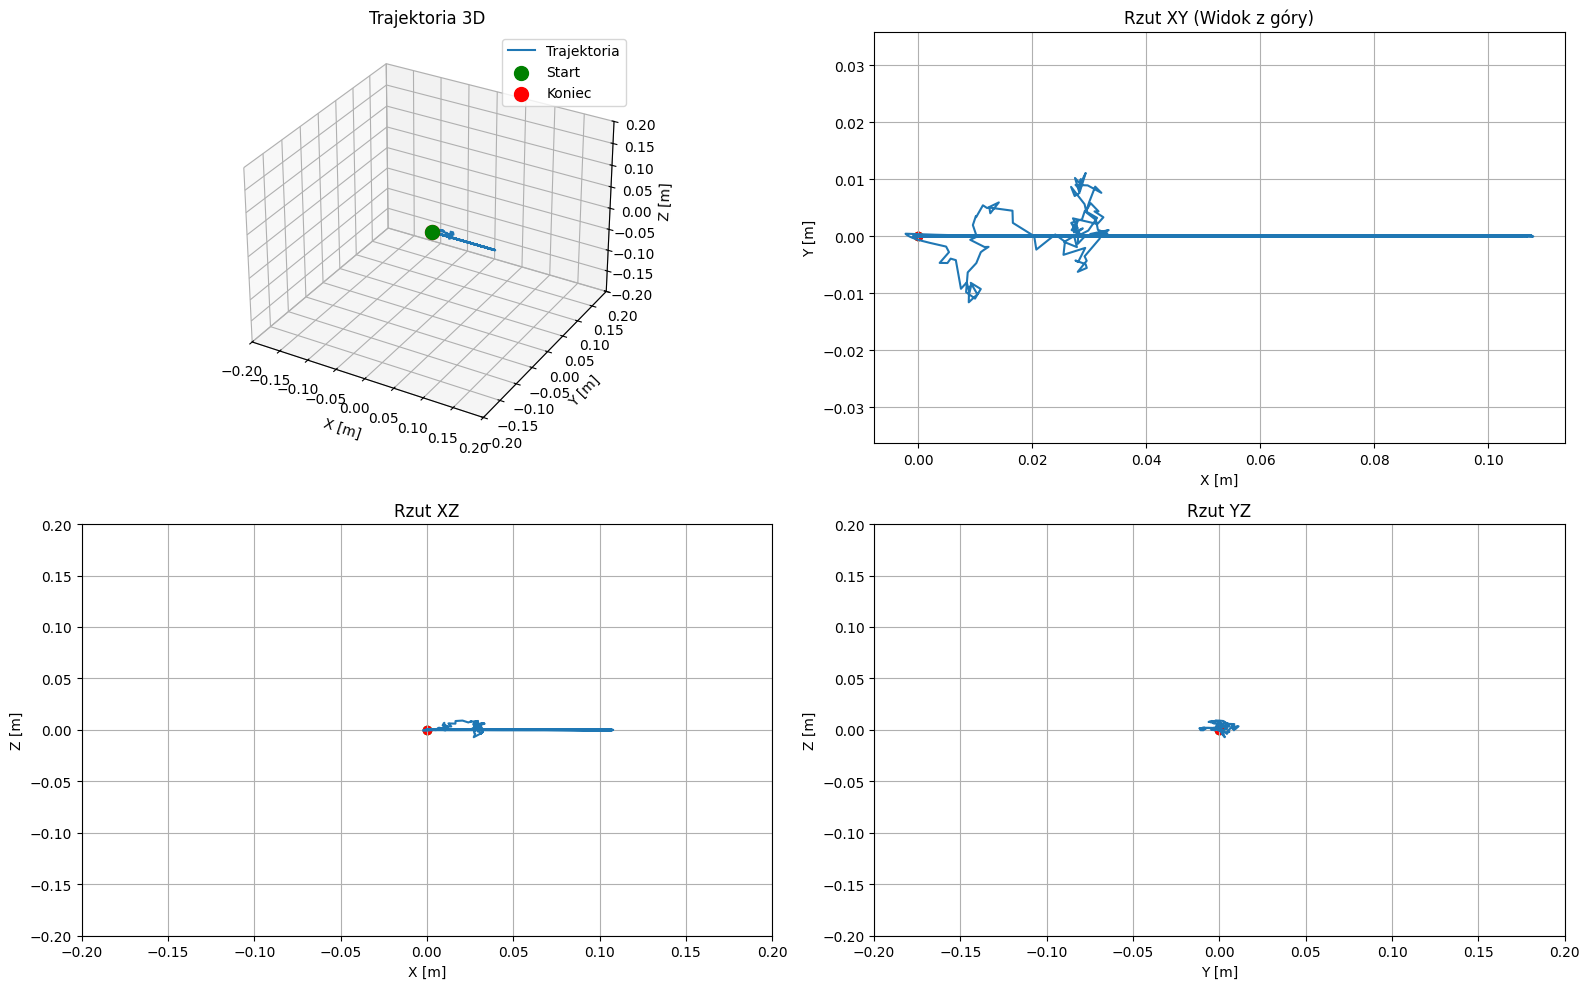

In [28]:
visualize_trajectory(df_final, method='fused', axis_size=0.2)

# Wyniki

In [29]:
print_final_metrics(calculate_final_metrics(df_final, gt_prefix='gt', method_prefix='fused'), method_name='Fused')

Metryki dryfu na 1s:
RMSE: 1.20 mm
Średni błąd: 0.67 mm
Mediana błędu: 0.10 mm

Metryki dryfu na 10s:
RMSE: 0.93 mm
Średni błąd: 0.57 mm
Mediana błędu: 0.10 mm


In [30]:
print_final_metrics(calculate_final_metrics(df_final, gt_prefix='gt', method_prefix='cam'), method_name='Camera Only')

Metryki dryfu na 1s:
RMSE: 2.38 mm
Średni błąd: 0.56 mm
Mediana błędu: 0.00 mm

Metryki dryfu na 10s:
RMSE: 0.66 mm
Średni błąd: 0.34 mm
Mediana błędu: 0.00 mm


In [31]:
print_final_metrics(calculate_final_metrics(df_final, gt_prefix='gt', method_prefix=method), method_name='IMU Only')

Metryki dryfu na 1s:
RMSE: 15.76 mm
Średni błąd: 12.33 mm
Mediana błędu: 8.94 mm

Metryki dryfu na 10s:
RMSE: 95.87 mm
Średni błąd: 60.25 mm
Mediana błędu: 32.69 mm


# Porównanie Fuzji

In [ ]:
LOOP_CLOSURE = False

In [122]:
fusion = SensorFusionEngine(df_sync_cam, imu_prefix=method)

df_fusion_weight_avg = fusion.approach_weighted_average(cam_trust=0.95, loop_closure=LOOP_CLOSURE)
df_fusion_comp_filter = fusion.approach_complementary_adaptive_filter(use_confidence=False, alpha_base=0.9, loop_closure=LOOP_CLOSURE)
# df_fusion_comp_adaptive_filter = fusion.approach_complementary_adaptive_filter(use_confidence=True, alpha_base=0.9, loop_closure=LOOP_CLOSURE)
df_fusion_err_drift_comp = fusion.approach_error_drift_compensation(smoothing_window=255, loop_closure=LOOP_CLOSURE)
df_fusion_kalman_filter = fusion.approach_kalman_adaptive_filter(use_confidence=False, loop_closure=LOOP_CLOSURE)
# df_fusion_kalman_adaptive_filter = fusion.approach_kalman_adaptive_filter(use_confidence=True, loop_closure=LOOP_CLOSURE)
df_fusion_wiener_filter = fusion.approach_wiener_filter(LOOP_CLOSURE)
df_fusion_camera_only = fusion.approach_weighted_average(cam_trust=1, loop_closure=LOOP_CLOSURE)

results = []
# for df in [df_fusion_weight_avg, df_fusion_comp_filter, df_fusion_comp_adaptive_filter, df_fusion_err_drift_comp, df_fusion_kalman_filter, df_fusion_kalman_adaptive_filter, df_fusion_wiener_filter, df_fusion_camera_only]:
for df in [df_fusion_weight_avg, df_fusion_comp_filter, df_fusion_err_drift_comp, df_fusion_kalman_filter, df_fusion_wiener_filter, df_fusion_camera_only]:
    results.append(calculate_final_metrics(df, gt_prefix='gt', method_prefix='fused'))
# results.append(calculate_final_metrics(df, gt_prefix='gt', method_prefix=method))
# results.append(calculate_final_metrics(df, gt_prefix='gt', method_prefix='cam'))

# method_names = ['Weighted Avg', 'Complementary Filter', 'Complementary Adaptive Filter', 'Error Drift Comp.', 'Kalman Filter', 'Kalman Adaptive Filter', 'Wiener Filter', 'Camera Only']
method_names = ['Weighted Avg', 'Complementary Filter', 'Error Drift Comp.', 'Kalman Filter', 'Wiener Filter', 'Camera Only']
for name, res in zip(method_names, results):
    print_final_metrics(res, method_name=name)
    print()    

Metryki dryfu na 1s:
RMSE: 0.59 mm
Średni błąd: 0.43 mm
Mediana błędu: 0.24 mm

Metryki dryfu na 10s:
RMSE: 4.79 mm
Średni błąd: 2.93 mm
Mediana błędu: 1.63 mm

Metryki dryfu na 1s:
RMSE: 0.76 mm
Średni błąd: 0.43 mm
Mediana błędu: 0.11 mm

Metryki dryfu na 10s:
RMSE: 0.99 mm
Średni błąd: 0.73 mm
Mediana błędu: 0.45 mm

Metryki dryfu na 1s:
RMSE: 0.60 mm
Średni błąd: 0.32 mm
Mediana błędu: 0.07 mm

Metryki dryfu na 10s:
RMSE: 0.64 mm
Średni błąd: 0.36 mm
Mediana błędu: 0.05 mm

Metryki dryfu na 1s:
RMSE: 1.09 mm
Średni błąd: 0.61 mm
Mediana błędu: 0.10 mm

Metryki dryfu na 10s:
RMSE: 0.93 mm
Średni błąd: 0.57 mm
Mediana błędu: 0.10 mm

Metryki dryfu na 1s:
RMSE: 0.57 mm
Średni błąd: 0.30 mm
Mediana błędu: 0.00 mm

Metryki dryfu na 10s:
RMSE: 0.66 mm
Średni błąd: 0.34 mm
Mediana błędu: 0.00 mm

Metryki dryfu na 1s:
RMSE: 0.57 mm
Średni błąd: 0.30 mm
Mediana błędu: 0.00 mm

Metryki dryfu na 10s:
RMSE: 0.66 mm
Średni błąd: 0.34 mm
Mediana błędu: 0.00 mm



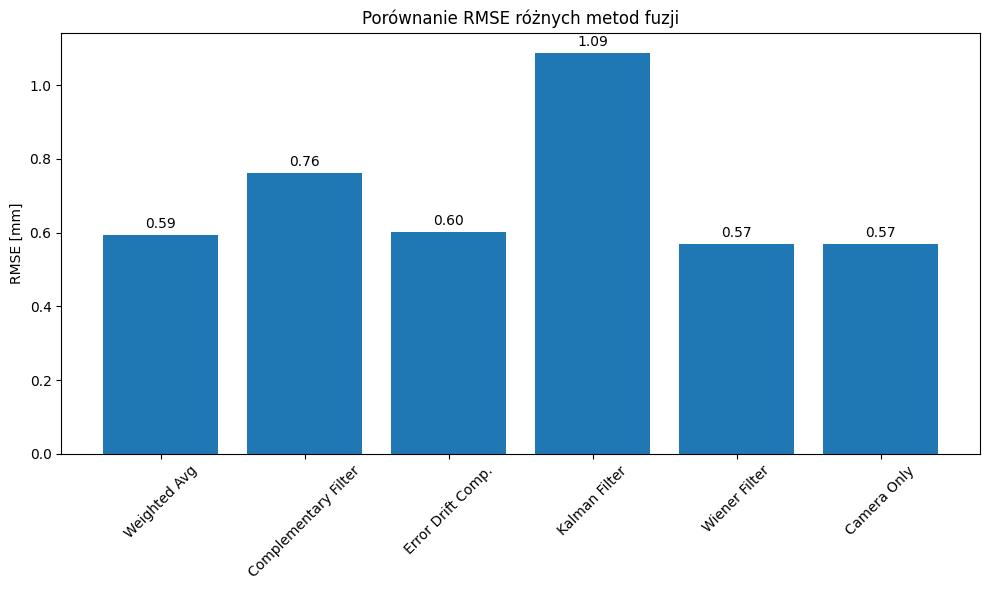

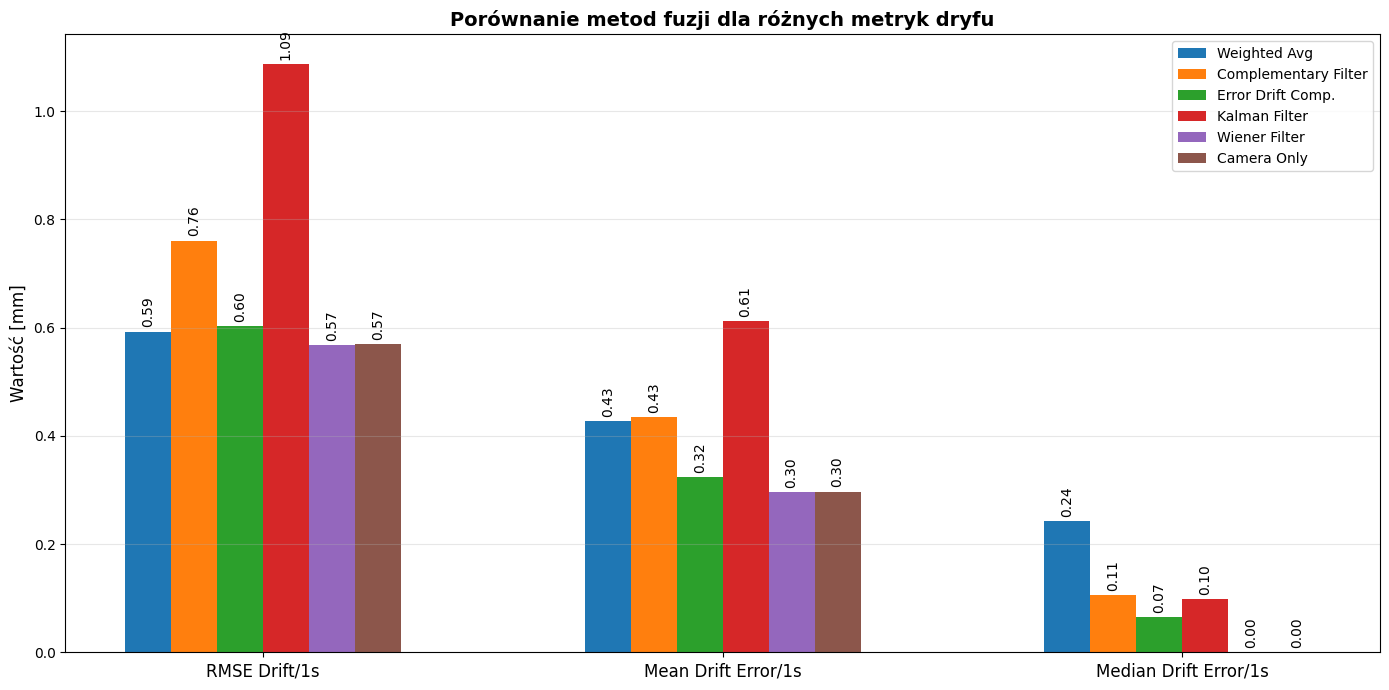

In [123]:
# metrics = ['rmse_drift_per_1s', 'mean_drift_error_per_1s', 'median_drift_error_per_1s', 'rmse_drift_per_10s', 'mean_drift_error_per_10s', 'median_drift_error_per_10s']
metrics = ['rmse_drift_per_1s', 'mean_drift_error_per_1s', 'median_drift_error_per_1s']
# metric_labels = ['RMSE Drift/1s', 'Mean Drift Error/1s', 'Median Drift Error/1s', 'RMSE Drift/10s', 'Mean Drift Error/10s', 'Median Drift Error/10s']
metric_labels = ['RMSE Drift/1s', 'Mean Drift Error/1s', 'Median Drift Error/1s']

# Wykres 1: RMSE drift per 1s
plt.figure(figsize=(10, 6))
plt.bar(method_names, [res['rmse_drift_per_1s'] for res in results])
plt.bar_label(plt.gca().containers[0], fmt='%.2f', padding=3, fontsize=10)
plt.ylabel('RMSE [mm]')
plt.title('Porównanie RMSE różnych metod fuzji')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Wykres 2: Wszystkie metryki - zgrupowane słupki
x = np.arange(len(metrics))
width = 0.10
fig, ax = plt.subplots(figsize=(14, 7))

# Dla każdej metody fuzji dodajemy słupki we wszystkich metrykach
for i, (method_name, res) in enumerate(zip(method_names, results)):
    values = [res[metric] for metric in metrics]
    offset = (i - len(method_names)/2) * width + width/2
    ax.bar(x + offset, values, width, label=method_name)
    ax.bar_label(ax.containers[i], fmt='%.2f', padding=3, fontsize=10, rotation=90)
    

# ax.set_xlabel('Metryki', fontsize=12)
ax.set_ylabel('Wartość [mm]', fontsize=12)
ax.set_title('Porównanie metod fuzji dla różnych metryk dryfu', fontsize=14, fontweight='bold')
ax.set_xticks(x)
# ax.set_xticklabels(metric_labels, rotation=45, ha='right')
ax.set_xticklabels(metric_labels, fontsize=12)
# ax.legend(loc='upper left', bbox_to_anchor=(1, 1))
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# Test fuzji na wszystkich danych

In [7]:
from funkcje_IMU import *
from funkcje_GT import *
from funkcje_IMU_GT import *
from funkcje_camera import *
from IMUFilter import *
from SensorFusionEngine import *


def whole_process_pipeline(path, method, loop_closure=False):
    file_path = 'Data_v2/'
    # IMU
    df_imu = load_IMU_data(file_path + path['imu'])
    df_imu = compute_orientation_and_global_acc(df_imu)
    df_imu = trim_IMU_data(df_imu, trim_start=1000, trim_end=500)
    df_imu = resample_IMU_data(df_imu, 100.0)
    # df_imu = remove_trend(df_imu)
    # df_imu = remove_moving_average_trend(df_imu)
    df_imu = remove_average_trend(df_imu)

    # Ground Truth
    df_gt = load_ground_truth(file_path + path['gt'])
    df_gt = trim_ground_truth(df_gt, trim_start=200, trim_end=200)
    df_gt = normalize_ground_truth(df_gt)
    df_gt = resample_ground_truth(df_gt, target_fps=100.0)
    df_gt = calculate_derivatives(df_gt)

    # Camera
    df_camera = load_camera_data(file_path + path['cam'])
    df_camera = resample_camera_data(df_camera, target_fps=100.0, current_fps=30.0)

    df_sync = synchronize_by_cross_correlation(df_imu, df_gt)
    IMU_filter = IMUFilter(fs=100.0)
    df_with_filters = IMU_filter.add_filtered_columns(df_sync, best_params)
    df_results = calculate_integrals(df_with_filters, method=method, use_detrend_vel=False, use_detrend_pos=False, use_loop_closure=loop_closure, apply_hp_filter=False)
    df_sync_cam = synchronize_imu_camera(df_results, df_camera, imu_prefix=method)
    # df_sync_cam = apply_camera_confidence(df_sync_cam, cam_prefix='cam', noise_type=True, conf_intervals=[(26.0, 27.0)])
    df_sync_cam = apply_camera_confidence(df_sync_cam, cam_prefix='cam', noise_type=True, conf_intervals=[(26.0, 27.0), (46, 47.0), (66.0, 67.0)])
    
    fusion = SensorFusionEngine(df_sync_cam, imu_prefix=method)

    df_fusion_weight_avg = fusion.approach_weighted_average(cam_trust=0.98, loop_closure=loop_closure)
    df_fusion_comp_filter = fusion.approach_complementary_adaptive_filter(use_confidence=False, alpha_base=0.9, loop_closure=loop_closure)
    df_fusion_comp_adaptive_filter = fusion.approach_complementary_adaptive_filter(use_confidence=True, alpha_base=0.9, loop_closure=loop_closure)
    df_fusion_err_drift_comp = fusion.approach_error_drift_compensation(smoothing_window=255, loop_closure=loop_closure)
    df_fusion_kalman_filter = fusion.approach_kalman_adaptive_filter(use_confidence=False, loop_closure=loop_closure)
    df_fusion_kalman_adaptive_filter = fusion.approach_kalman_adaptive_filter(use_confidence=True, loop_closure=loop_closure)
    df_fusion_wiener_filter = fusion.approach_wiener_filter(loop_closure)
    df_fusion_camera_only = fusion.approach_weighted_average(cam_trust=1, loop_closure=loop_closure)

    results = []
    for df in [df_fusion_weight_avg, df_fusion_comp_filter, df_fusion_comp_adaptive_filter, df_fusion_err_drift_comp, df_fusion_kalman_filter, df_fusion_kalman_adaptive_filter, df_fusion_wiener_filter, df_fusion_camera_only]:
    # for df in [df_fusion_weight_avg, df_fusion_comp_filter, df_fusion_err_drift_comp, df_fusion_kalman_filter, df_fusion_wiener_filter, df_fusion_camera_only]:
        results.append(calculate_final_metrics(df, gt_prefix='gt', method_prefix='fused'))
    # results.append(calculate_final_metrics(df, gt_prefix='gt', method_prefix=method))
    # results.append(calculate_final_metrics(df, gt_prefix='gt', method_prefix='cam'))
    return results


In [11]:
whole_results = {}
for name, paths in data_files.items():
    if name.startswith('rotation'):
        continue
    print(f"Przetwarzanie zbioru danych: {name}")
    whole_results[name] = whole_process_pipeline(paths, method='gl', loop_closure=True)

Przetwarzanie zbioru danych: horizontal_line_1
=== Synchronizacja przez korelację krzyżową ===
Obliczone przesunięcie: -265 próbek
=== Synchronizacja przez korelację krzyżową ===
Obliczone przesunięcie: 18 próbek
Przetwarzanie zbioru danych: horizontal_line_2
=== Synchronizacja przez korelację krzyżową ===
Obliczone przesunięcie: 30 próbek
=== Synchronizacja przez korelację krzyżową ===
Obliczone przesunięcie: 25 próbek
Przetwarzanie zbioru danych: vertical_line_1
=== Synchronizacja przez korelację krzyżową ===
Obliczone przesunięcie: -168 próbek
=== Synchronizacja przez korelację krzyżową ===
Obliczone przesunięcie: -125 próbek
Przetwarzanie zbioru danych: vertical_line_2
=== Synchronizacja przez korelację krzyżową ===
Obliczone przesunięcie: -155 próbek
=== Synchronizacja przez korelację krzyżową ===
Obliczone przesunięcie: -130 próbek
Przetwarzanie zbioru danych: square_1
=== Synchronizacja przez korelację krzyżową ===
Obliczone przesunięcie: -1 próbek
=== Synchronizacja przez korel

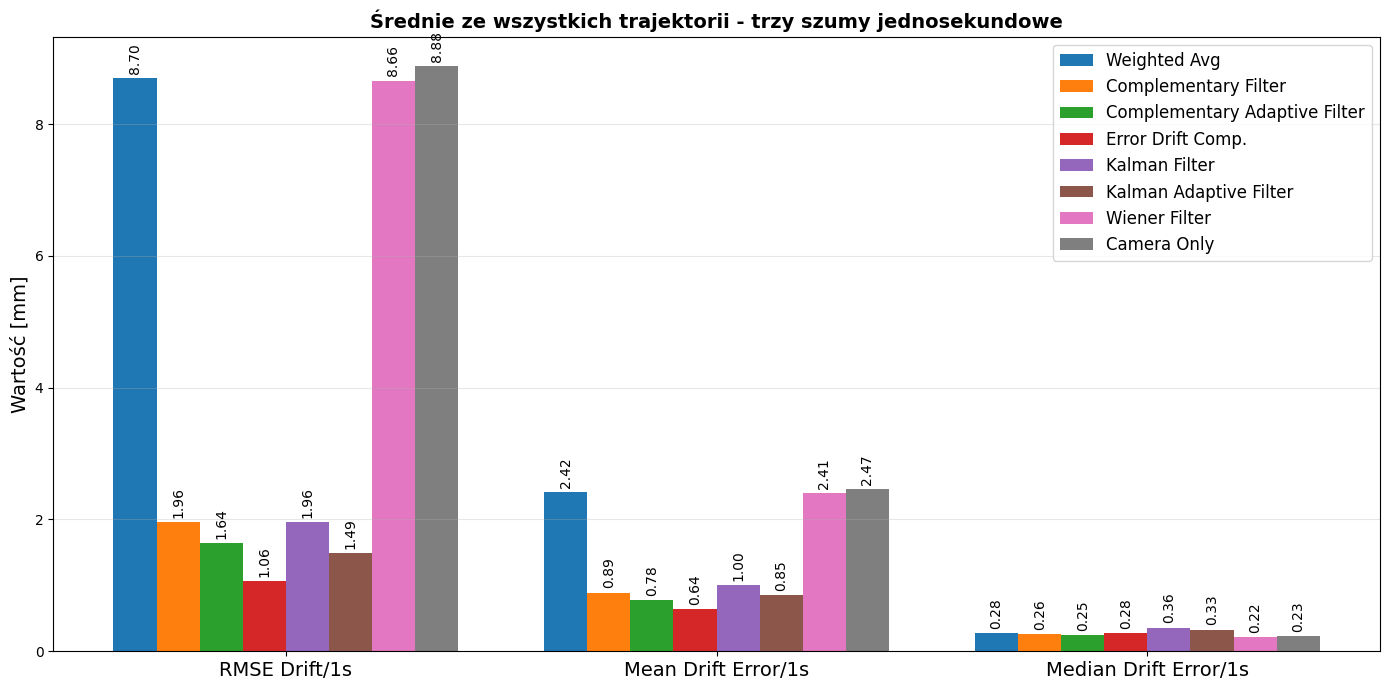

Weighted Avg          8.699232              2.422326              0.282122              
Complementary Filter  1.957935              0.892065              0.263915              
Complementary Adaptive Filter1.642131              0.780965              0.252026              
Error Drift Comp.     1.059123              0.644763              0.279620              
Kalman Filter         1.956158              1.001810              0.359566              
Kalman Adaptive Filter1.485945              0.851032              0.330082              
Wiener Filter         8.661431              2.407198              0.217493              
Camera Only           8.881319              2.467059              0.229497              


In [12]:
# Lista metod (zakładam kolejność jak w danych)
method_names = ['Weighted Avg', 'Complementary Filter', 'Complementary Adaptive Filter',  'Error Drift Comp.', 'Kalman Filter', 'Kalman Adaptive Filter', 'Wiener Filter', 'Camera Only']   
# method_names = ['Weighted Avg', 'Complementary Filter',  'Error Drift Comp.', 'Kalman Filter', 'Wiener Filter', 'Camera Only']   
# metrics = ['rmse_drift_per_1s', 'mean_drift_error_per_1s', 'median_drift_error_per_1s', 'rmse_drift_per_10s', 'mean_drift_error_per_10s', 'median_drift_error_per_10s']
metrics = ['rmse_drift_per_1s', 'mean_drift_error_per_1s', 'median_drift_error_per_1s']
# metric_labels = ['RMSE Drift/1s', 'Mean Drift Error/1s', 'Median Drift Error/1s', 'RMSE Drift/10s', 'Mean Drift Error/10s', 'Median Drift Error/10s']
metric_labels = ['RMSE Drift/1s', 'Mean Drift Error/1s', 'Median Drift Error/1s']
# Oblicz średnie dla każdej metody (po wszystkich trajektoriach)
avg_results = []
for method_idx in range(len(method_names)):
    method_avg = {}
    for metric in metrics:
        # Zbierz wartości tej metryki dla tej metody ze wszystkich trajektorii
        values = [whole_results[traj][method_idx][metric] for traj in whole_results.keys()]
        method_avg[metric] = np.mean(values)
    avg_results.append(method_avg)

# Wykres: zgrupowane słupki dla wszystkich metryk
x = np.arange(len(metrics))
width = 0.10  # Szerokość pojedynczego słupka

fig, ax = plt.subplots(figsize=(14, 7))

for i, (method_name, res) in enumerate(zip(method_names, avg_results)):
    values = [res[metric] for metric in metrics]
    offset = (i - len(method_names)/2) * width + width/2
    ax.bar(x + offset, values, width, label=method_name)
    ax.bar_label(ax.containers[i], fmt='%.2f', padding=3, fontsize=10, rotation=90)

# ax.set_xlabel('Metryki', fontsize=12)
ax.set_ylabel('Wartość [mm]', fontsize=14)
ax.set_title('Średnie ze wszystkich trajektorii - trzy szumy jednosekundowe', fontsize=14, fontweight='bold')
ax.set_xticks(x)
# ax.set_xticklabels(metric_labels, rotation=45, ha='right')
ax.set_xticklabels(metric_labels, fontsize=14)
# ax.legend(loc='upper left', bbox_to_anchor=(1, 1))
ax.legend(fontsize=12)
ax.grid(True, axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# # Dodatkowo: wykres tylko RMSE dla lepszej czytelności
# plt.figure(figsize=(10, 6))
# rmse_values = [res['rmse_drift_per_1s'] for res in avg_results]
# bars = plt.bar(method_names, rmse_values)
# plt.ylabel('RMSE [mm]', fontsize=12)
# plt.title('Porównanie RMSE - średnie ze wszystkich trajektorii', fontsize=14, fontweight='bold')
# plt.xticks(rotation=45, ha='right')
# plt.grid(True, axis='y', alpha=0.3)

# # Dodanie wartości na słupkach
# for bar, val in zip(bars, rmse_values):
#     plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001, 
#              f'{val:.2f}', ha='center', va='bottom', fontsize=9)

# plt.tight_layout()
# plt.show()

# # Wyświetl tabelę ze średnimi wynikami
# print("\nŚREDNIE WYNIKI DLA WSZYSTKICH TRAJEKTORII:")
# print("="*100)
# print(f"{'Metoda':<22}", end="")
# for metric_label in metric_labels:
#     print(f"{metric_label:<22}", end="")
# print()
# print("-"*100)

for method_name, res in zip(method_names, avg_results):
    print(f"{method_name:<22}", end="")
    for metric in metrics:
        print(f"{res[metric]:<22.6f}", end="")
    print()
print("="*100)


# Test filtrów IMU na wszystkich danych

In [30]:
def test_filters_on_all_data(data_files, best_params):
    filter_results = {}
    for name, paths in data_files.items():
        if name.startswith('rotation'):
            continue
        print(f"Przetwarzanie zbioru danych: {name}")
        file_path = 'Data_v2/'
        df_imu = load_IMU_data(file_path + paths['imu'])
        df_imu = compute_orientation_and_global_acc(df_imu)
        df_imu = trim_IMU_data(df_imu, trim_start=1000, trim_end=500)
        df_imu = resample_IMU_data(df_imu, 100.0)
        df_imu = remove_average_trend(df_imu)

        df_gt = load_ground_truth(file_path + paths['gt'])
        df_gt = trim_ground_truth(df_gt, trim_start=200, trim_end=200)
        df_gt = normalize_ground_truth(df_gt)
        df_gt = resample_ground_truth(df_gt, target_fps=100.0)
        df_gt = calculate_derivatives(df_gt)

        df_sync = synchronize_by_cross_correlation(df_imu, df_gt)
        IMU_filter = IMUFilter(fs=100.0)
        df_with_filters = IMU_filter.add_filtered_columns(df_sync, best_params)

        results = calculate_rmse_vs_gt(df_with_filters)
        filter_results[name] = results
    return filter_results

In [31]:
filter_results = test_filters_on_all_data(data_files, best_params)
print(filter_results)

Przetwarzanie zbioru danych: horizontal_line_1


=== Synchronizacja przez korelację krzyżową ===
Obliczone przesunięcie: -265 próbek
Przetwarzanie zbioru danych: horizontal_line_2
=== Synchronizacja przez korelację krzyżową ===
Obliczone przesunięcie: 30 próbek
Przetwarzanie zbioru danych: vertical_line_1
=== Synchronizacja przez korelację krzyżową ===
Obliczone przesunięcie: -168 próbek
Przetwarzanie zbioru danych: vertical_line_2
=== Synchronizacja przez korelację krzyżową ===
Obliczone przesunięcie: -155 próbek
Przetwarzanie zbioru danych: square_1
=== Synchronizacja przez korelację krzyżową ===
Obliczone przesunięcie: -1 próbek
Przetwarzanie zbioru danych: square_2
=== Synchronizacja przez korelację krzyżową ===
Obliczone przesunięcie: -39 próbek
Przetwarzanie zbioru danych: triangle_1
=== Synchronizacja przez korelację krzyżową ===
Obliczone przesunięcie: -151 próbek
Przetwarzanie zbioru danych: triangle_2
=== Synchronizacja przez korelację krzyżową ===
Obliczone przesunięcie: -99 próbek
Przetwarzanie zbioru danych: cross_1
=== 

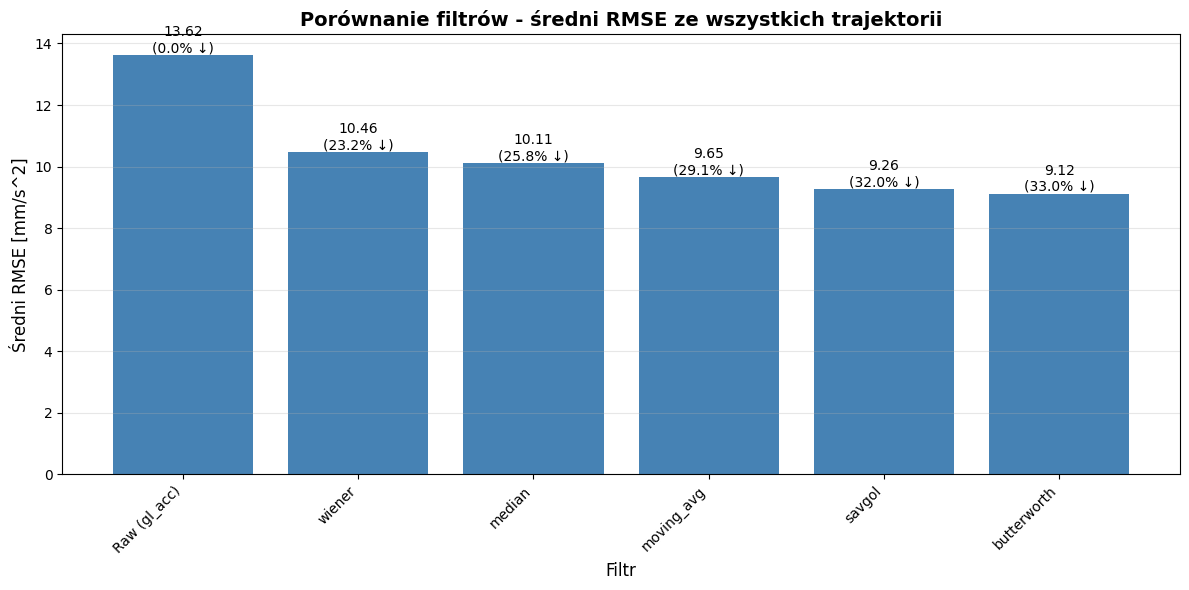


Raw (gl_acc) RMSE: 13.62 mm
--------------------------------------------------
Raw (gl_acc)    | RMSE: 13.62 | poprawa: 0.00%
wiener          | RMSE: 10.46 | poprawa: 23.19%
median          | RMSE: 10.11 | poprawa: 25.78%
moving_avg      | RMSE: 9.65 | poprawa: 29.14%
savgol          | RMSE: 9.26 | poprawa: 32.02%
butterworth     | RMSE: 9.12 | poprawa: 33.04%


In [34]:
# Średnie RMSE (pomijając 'original')
filter_rmse = {}
for filter_name in [f[0] for f in list(filter_results.values())[0] if f[0] != 'original']:
    values = []
    for traj in filter_results.values():
        for name, val in traj:
            if name == filter_name:
                values.append(val)
                break
    filter_rmse[filter_name] = np.mean(values) * 1000  # Konwersja na mm/s^2

raw_rmse = filter_rmse.get('Raw (gl_acc)', None)

# Sortuj według RMSE
sorted_filters = sorted(filter_rmse.items(), key=lambda x: -x[1])
filter_names = [f[0] for f in sorted_filters]
rmse_values = [f[1] for f in sorted_filters]

plt.figure(figsize=(12, 6))
bars = plt.bar(filter_names, rmse_values, color='steelblue')

# Etykiety z procentową poprawą względem Raw
for bar, rmse in zip(bars, rmse_values):
    gain = ((raw_rmse - rmse) / raw_rmse) * 100
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.0002, 
             f'{rmse:.2f}\n({gain:.1f}% ↓)', 
             ha='center', va='bottom', fontsize=10)

plt.ylabel('Średni RMSE [mm/s^2]', fontsize=12)
plt.xlabel('Filtr', fontsize=12)
plt.title('Porównanie filtrów - średni RMSE ze wszystkich trajektorii', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# Wypisz procentową poprawę
print(f"\nRaw (gl_acc) RMSE: {raw_rmse:.2f} mm")
print("-" * 50)
for name, rmse in sorted_filters:
    gain = ((raw_rmse - rmse) / raw_rmse) * 100
    print(f"{name:15} | RMSE: {rmse:.2f} | poprawa: {gain:.2f}%")

# Wyniki filtrów IMU na wszystkich danych

In [142]:
from funkcje_IMU import *
from funkcje_GT import *
from funkcje_IMU_GT import *
from funkcje_camera import *
from IMUFilter import *
from SensorFusionEngine import *


def whole_process_pipeline(path, loop_closure=False):
    file_path = 'Data_v2/'
    # IMU
    df_imu = load_IMU_data(file_path + path['imu'])
    df_imu = compute_orientation_and_global_acc(df_imu)
    df_imu = trim_IMU_data(df_imu, trim_start=1000, trim_end=500)
    df_imu = resample_IMU_data(df_imu, 100.0)
    # df_imu = remove_trend(df_imu)
    # df_imu = remove_moving_average_trend(df_imu)
    df_imu = remove_average_trend(df_imu)

    # Ground Truth
    df_gt = load_ground_truth(file_path + path['gt'])
    df_gt = trim_ground_truth(df_gt, trim_start=200, trim_end=200)
    df_gt = normalize_ground_truth(df_gt)
    df_gt = resample_ground_truth(df_gt, target_fps=100.0)
    df_gt = calculate_derivatives(df_gt)

    # Camera
    df_camera = load_camera_data(file_path + path['cam'])
    df_camera = resample_camera_data(df_camera, target_fps=100.0, current_fps=30.0)

    df_sync = synchronize_by_cross_correlation(df_imu, df_gt)
    IMU_filter = IMUFilter(fs=100.0)
    df_with_filters = IMU_filter.add_filtered_columns(df_sync, best_params)

    results = []
    for method_name in ["gl", "butterworth", "savgol", "moving_avg", "median", "wiener"]:
        df_with_filters = calculate_integrals(df_with_filters, method=method_name, use_detrend_vel=False, use_detrend_pos=False, use_loop_closure=loop_closure, apply_hp_filter=False)
        print(f"Obliczanie metryk dla metody: {method_name}")
        print_final_metrics(calculate_final_metrics(df_with_filters, gt_prefix='gt', method_prefix=method_name), method_name=method_name)
        results.append(calculate_final_metrics(df_with_filters, gt_prefix='gt', method_prefix=method_name))

    return results

In [175]:
whole_results = {}
for name, paths in data_files.items():
    if name.startswith('rotation'):
        continue
    print(f"Przetwarzanie zbioru danych: {name}")
    whole_results[name] = whole_process_pipeline(paths, loop_closure=False)

Przetwarzanie zbioru danych: horizontal_line_1
=== Synchronizacja przez korelację krzyżową ===
Obliczone przesunięcie: -265 próbek
Obliczanie metryk dla metody: gl
Metryki dryfu na 1s:
RMSE: 15.72 mm
Średni błąd: 12.28 mm
Mediana błędu: 9.24 mm

Metryki dryfu na 10s:
RMSE: 95.51 mm
Średni błąd: 59.78 mm
Mediana błędu: 32.51 mm
Obliczanie metryk dla metody: butterworth
Metryki dryfu na 1s:
RMSE: 15.73 mm
Średni błąd: 12.30 mm
Mediana błędu: 9.19 mm

Metryki dryfu na 10s:
RMSE: 95.59 mm
Średni błąd: 59.93 mm
Mediana błędu: 32.03 mm
Obliczanie metryk dla metody: savgol
Metryki dryfu na 1s:
RMSE: 15.72 mm
Średni błąd: 12.29 mm
Mediana błędu: 9.22 mm

Metryki dryfu na 10s:
RMSE: 95.54 mm
Średni błąd: 59.81 mm
Mediana błędu: 32.33 mm
Obliczanie metryk dla metody: moving_avg
Metryki dryfu na 1s:
RMSE: 15.72 mm
Średni błąd: 12.29 mm
Mediana błędu: 9.25 mm

Metryki dryfu na 10s:
RMSE: 95.52 mm
Średni błąd: 59.85 mm
Mediana błędu: 32.61 mm
Obliczanie metryk dla metody: median
Metryki dryfu na 1s

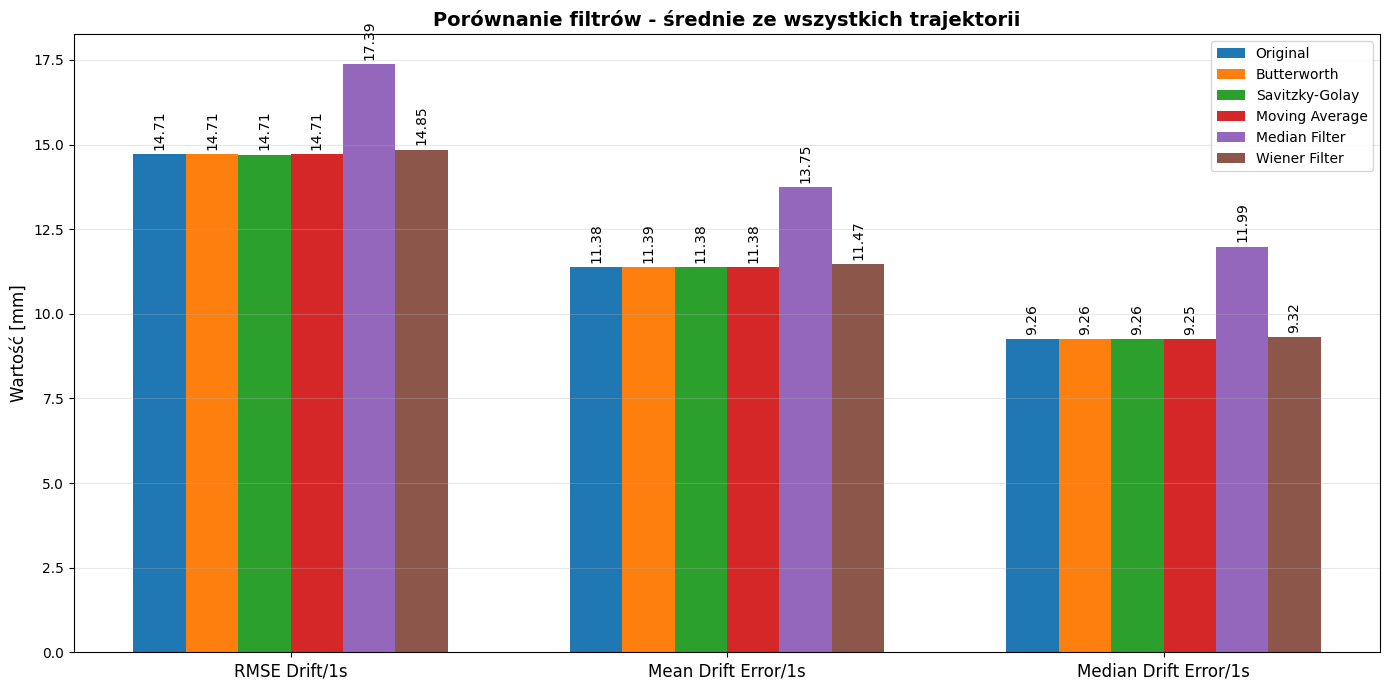

In [177]:
# Lista metod (zakładam kolejność jak w danych)
# ["gl", "butterworth", "savgol", "moving_avg", "median", "wiener"]
filter_names = ["Original", "Butterworth", "Savitzky-Golay", "Moving Average", "Median Filter", "Wiener Filter"]
# metrics = ['rmse_drift_per_1s', 'mean_drift_error_per_1s', 'median_drift_error_per_1s', 'rmse_drift_per_10s', 'mean_drift_error_per_10s', 'median_drift_error_per_10s']
metrics = ['rmse_drift_per_1s', 'mean_drift_error_per_1s', 'median_drift_error_per_1s']
# metric_labels = ['RMSE Drift/1s', 'Mean Drift Error/1s', 'Median Drift Error/1s', 'RMSE Drift/10s', 'Mean Drift Error/10s', 'Median Drift Error/10s']
metric_labels = ['RMSE Drift/1s', 'Mean Drift Error/1s', 'Median Drift Error/1s']
# Oblicz średnie dla każdej metody (po wszystkich trajektoriach)
avg_results = []
for filter_idx in range(len(filter_names)):
    filter_avg = {}
    for metric in metrics:
        # Zbierz wartości tej metryki dla tej metody ze wszystkich trajektorii
        values = [whole_results[traj][filter_idx][metric] for traj in whole_results.keys()]
        filter_avg[metric] = np.mean(values)
    avg_results.append(filter_avg)

# Wykres: zgrupowane słupki dla wszystkich metryk
x = np.arange(len(metrics))
width = 0.12  # Szerokość pojedynczego słupka

fig, ax = plt.subplots(figsize=(14, 7))

for i, (method_name, res) in enumerate(zip(filter_names, avg_results)):
    values = [res[metric] for metric in metrics]
    offset = (i - len(filter_names)/2) * width + width/2
    ax.bar(x + offset, values, width, label=method_name)
    ax.bar_label(ax.containers[i], fmt='%.2f', padding=3, fontsize=10, rotation=90)

# ax.set_xlabel('Metryki', fontsize=12)
ax.set_ylabel('Wartość [mm]', fontsize=12)
ax.set_title('Porównanie filtrów - średnie ze wszystkich trajektorii', fontsize=14, fontweight='bold')
ax.set_xticks(x)
# ax.set_xticklabels(metric_labels, rotation=45, ha='right')
ax.set_xticklabels(metric_labels, fontsize=12)
# ax.legend(loc='upper left', bbox_to_anchor=(1, 1))
ax.legend()
ax.grid(True, axis='y', alpha=0.3)

plt.tight_layout()
plt.show()



# Testowanie parametrów dla fuzji

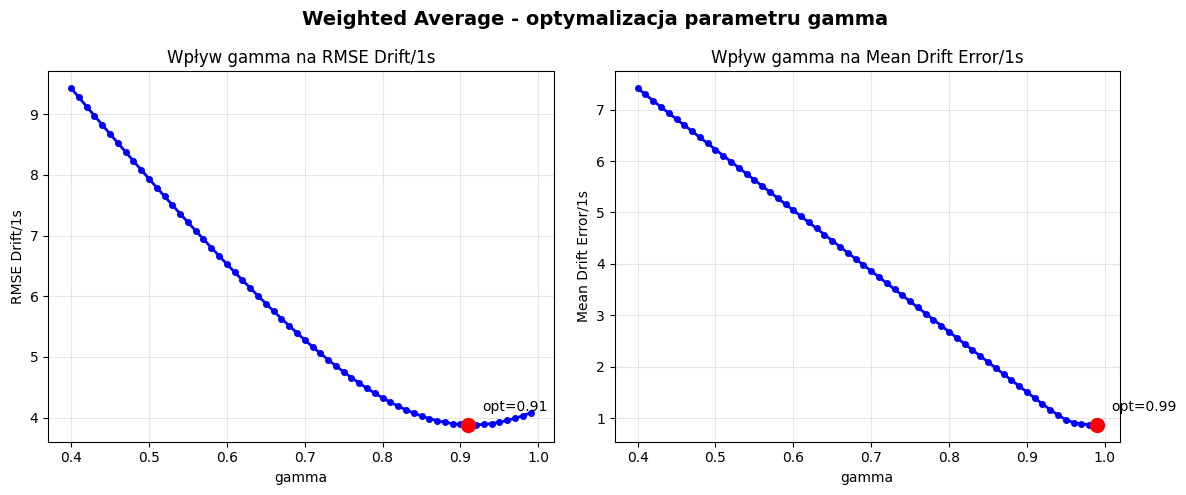

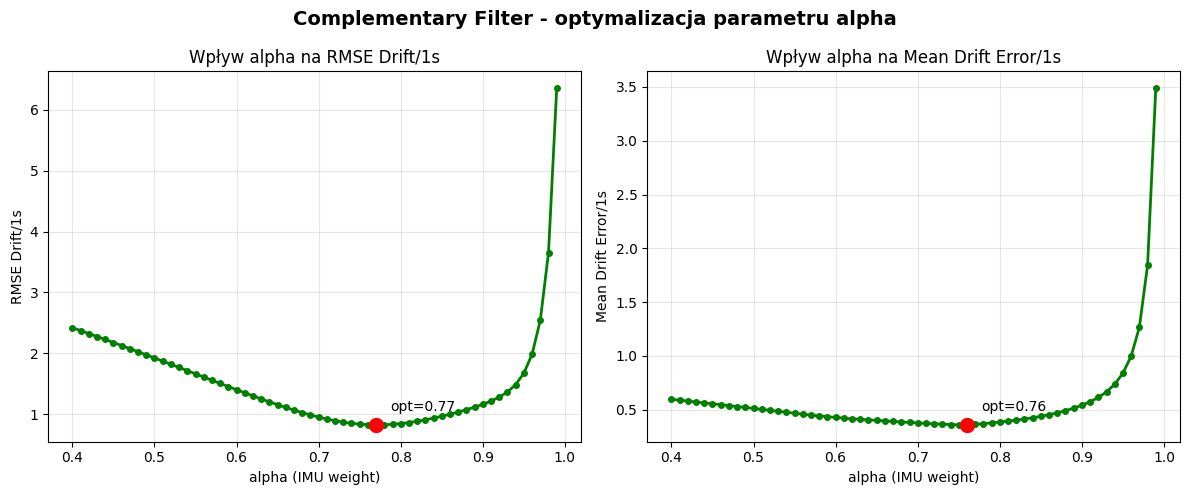

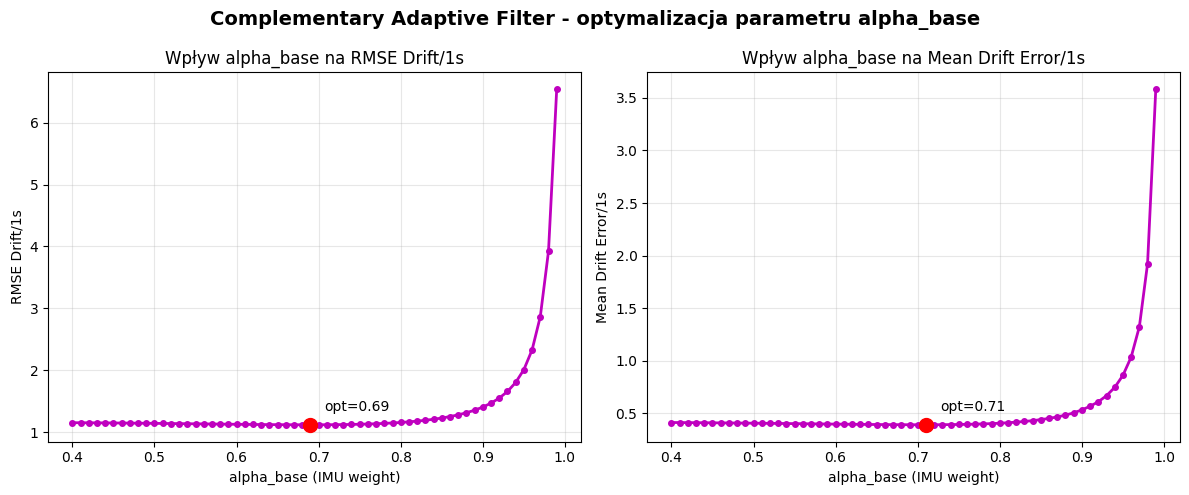

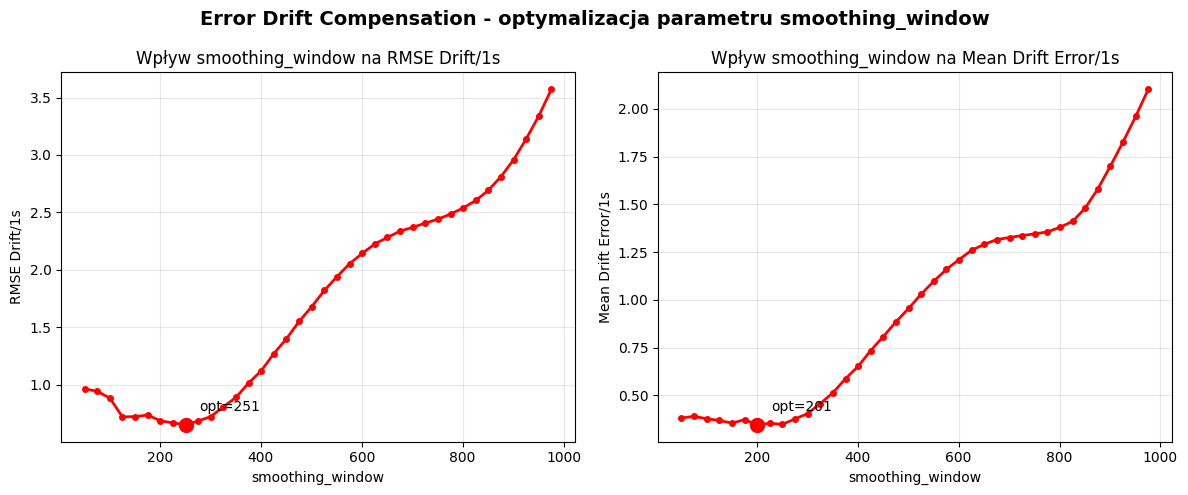

In [138]:
import matplotlib.pyplot as plt
import numpy as np

# Testowanie parametru cam_trust dla weighted average
results_cam_trust = []
cam_trust_values = np.arange(0.4, 1.00, 0.01)

for t in cam_trust_values:
    df_fusion_weight_avg = fusion.approach_weighted_average(cam_trust=t, loop_closure=LOOP_CLOSURE)
    results_cam_trust.append(calculate_final_metrics(df_fusion_weight_avg, gt_prefix='gt', method_prefix='fused'))

# Testowanie parametru alpha dla complementary filter
results_alpha = []
alpha_values = np.arange(0.4, 1.00, 0.01)

for a in alpha_values:
    df_fusion_comp_filter = fusion.approach_complementary_adaptive_filter(use_confidence=False, alpha_base=a, loop_closure=LOOP_CLOSURE)
    results_alpha.append(calculate_final_metrics(df_fusion_comp_filter, gt_prefix='gt', method_prefix='fused'))

# Testowanie parametru alpha dla complementary adaptive filter
results_alpha_adaptive = []
alpha_values_adaptive = np.arange(0.4, 1.00, 0.01)

for a in alpha_values_adaptive:
    df_fusion_comp_adaptive = fusion.approach_complementary_adaptive_filter(use_confidence=True, alpha_base=a, loop_closure=LOOP_CLOSURE)
    results_alpha_adaptive.append(calculate_final_metrics(df_fusion_comp_adaptive, gt_prefix='gt', method_prefix='fused'))

# Testowanie parametru smoothing_window dla error drift compensation
results_window = []
window_values = range(51, 1001, 25)  # od 50 do 500 co 50

for w in window_values:
    df_fusion_err_drift_comp = fusion.approach_error_drift_compensation(smoothing_window=w, loop_closure=LOOP_CLOSURE)
    results_window.append(calculate_final_metrics(df_fusion_err_drift_comp, gt_prefix='gt', method_prefix='fused'))


# Wykres 1: Wpływ cam_trust na metryki
metrics = ['rmse_drift_per_1s', 'mean_drift_error_per_1s']
# metrics = ['rmse_drift_per_1s', 'median_drift_error_per_1s']
metric_labels = ['RMSE Drift/1s', 'Mean Drift Error/1s']
# metric_labels = ['RMSE Drift/1s', 'Median Drift Error/1s']

plt.figure(figsize=(12, 5))
for i, (metric, label) in enumerate(zip(metrics, metric_labels)):
    plt.subplot(1, 2, i+1)
    values = [res[metric] for res in results_cam_trust]
    plt.plot(cam_trust_values, values, 'b.-', linewidth=2, markersize=8)
    plt.xlabel('gamma')
    plt.ylabel(label)
    plt.title(f'Wpływ gamma na {label}')
    plt.grid(True, alpha=0.3)
    # Zaznaczenie optymalnej wartości (minimum)
    min_idx = np.argmin(values)
    plt.plot(cam_trust_values[min_idx], values[min_idx], 'ro', markersize=10)
    plt.annotate(f'opt={cam_trust_values[min_idx]:.2f}', 
                 xy=(cam_trust_values[min_idx], values[min_idx]),
                 xytext=(10, 10), textcoords='offset points')
plt.suptitle('Weighted Average - optymalizacja parametru gamma', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Wykres 2: Wpływ alpha na metryki
plt.figure(figsize=(12, 5))
for i, (metric, label) in enumerate(zip(metrics, metric_labels)):
    plt.subplot(1, 2, i+1)
    values = [res[metric] for res in results_alpha]
    plt.plot(alpha_values, values, 'g.-', linewidth=2, markersize=8)
    plt.xlabel('alpha (IMU weight)')
    plt.ylabel(label)
    plt.title(f'Wpływ alpha na {label}')
    plt.grid(True, alpha=0.3)
    # Zaznaczenie optymalnej wartości
    min_idx = np.argmin(values)
    plt.plot(alpha_values[min_idx], values[min_idx], 'ro', markersize=10)
    plt.annotate(f'opt={alpha_values[min_idx]:.2f}', 
                 xy=(alpha_values[min_idx], values[min_idx]),
                 xytext=(10, 10), textcoords='offset points')
plt.suptitle('Complementary Filter - optymalizacja parametru alpha', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

#Wykres 3: Wpływ alpha adaptive na metryki
plt.figure(figsize=(12, 5))
for i, (metric, label) in enumerate(zip(metrics, metric_labels)):
    plt.subplot(1, 2, i+1)
    values = [res[metric] for res in results_alpha_adaptive]
    plt.plot(alpha_values_adaptive, values, 'm.-', linewidth=2, markersize=8)
    plt.xlabel('alpha_base (IMU weight)')
    plt.ylabel(label)
    plt.title(f'Wpływ alpha_base na {label}')
    plt.grid(True, alpha=0.3)
    # Zaznaczenie optymalnej wartości
    min_idx = np.argmin(values)
    plt.plot(alpha_values_adaptive[min_idx], values[min_idx], 'ro', markersize=10)
    plt.annotate(f'opt={alpha_values_adaptive[min_idx]:.2f}', 
                 xy=(alpha_values_adaptive[min_idx], values[min_idx]),
                 xytext=(10, 10), textcoords='offset points')
plt.suptitle('Complementary Adaptive Filter - optymalizacja parametru alpha_base', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Wykres 4: Wpływ smoothing_window na metryki
plt.figure(figsize=(12, 5))
for i, (metric, label) in enumerate(zip(metrics, metric_labels)):
    plt.subplot(1, 2, i+1)
    values = [res[metric] for res in results_window]
    plt.plot(window_values, values, 'r.-', linewidth=2, markersize=8)
    plt.xlabel('smoothing_window')
    plt.ylabel(label)
    plt.title(f'Wpływ smoothing_window na {label}')
    plt.grid(True, alpha=0.3)
    # Zaznaczenie optymalnej wartości
    min_idx = np.argmin(values)
    plt.plot(window_values[min_idx], values[min_idx], 'ro', markersize=10)
    plt.annotate(f'opt={window_values[min_idx]}', 
                 xy=(window_values[min_idx], values[min_idx]),
                 xytext=(10, 10), textcoords='offset points')
plt.suptitle('Error Drift Compensation - optymalizacja parametru smoothing_window', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


PRZETWARZANIE I OPTYMALIZACJA DLA: horizontal_line_1
=== Synchronizacja przez korelację krzyżową ===
Obliczone przesunięcie: -265 próbek
=== Synchronizacja przez korelację krzyżową ===
Obliczone przesunięcie: -202 próbek


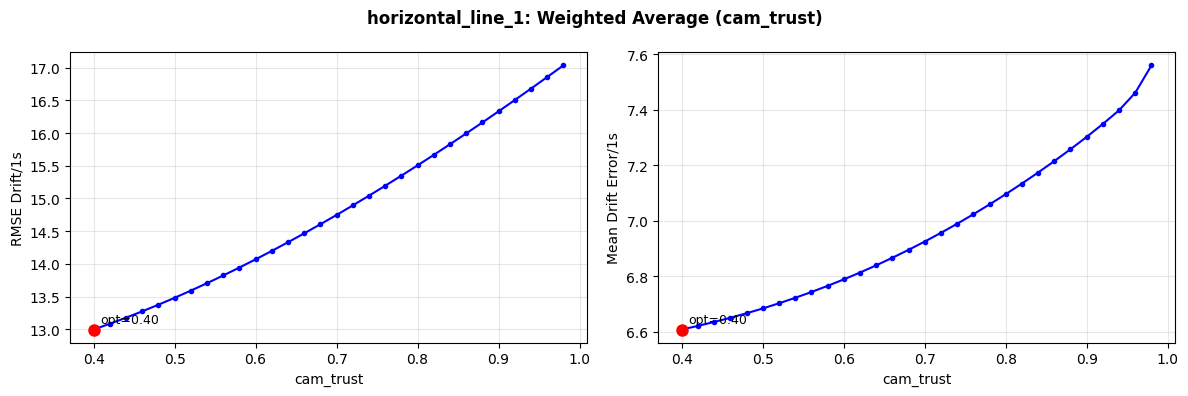

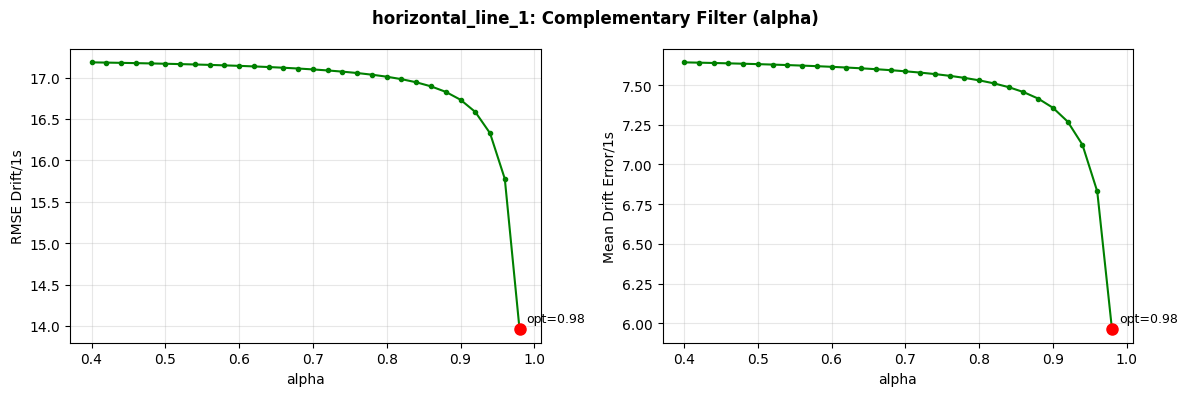

KeyError: 'cam_conf'

In [106]:
import matplotlib.pyplot as plt
import numpy as np

# --- KONFIGURACJA ZAKRESÓW ---
cam_trust_values = np.arange(0.4, 1.00, 0.02)
alpha_values = np.arange(0.4, 1.00, 0.02)
window_values = list(range(51, 1001, 50))
LOOP_CLOSURE = False
metrics_to_plot = ['rmse_drift_per_1s', 'mean_drift_error_per_1s']
metric_labels = ['RMSE Drift/1s', 'Mean Drift Error/1s']

# Struktury do przechowywania wyników ze wszystkich plików (do średniej)
global_results = {
    'cam_trust': [], # lista list wyników
    'alpha': [],
    'alpha_adaptive': [],
    'window': []
}

def plot_opt_results(x_vals, results, title, color, x_label):
    """Funkcja pomocnicza do rysowania dwóch wykresów optymalizacji obok siebie"""
    plt.figure(figsize=(12, 4))
    for i, (metric, label) in enumerate(zip(metrics_to_plot, metric_labels)):
        plt.subplot(1, 2, i+1)
        values = [res[metric] for res in results]
        plt.plot(x_vals, values, color + '.-', linewidth=1.5, markersize=6)
        plt.xlabel(x_label)
        plt.ylabel(label)
        plt.grid(True, alpha=0.3)
        
        min_idx = np.argmin(values)
        plt.plot(x_vals[min_idx], values[min_idx], 'ro', markersize=8)
        plt.annotate(f'opt={x_vals[min_idx]:.2f}', 
                     xy=(x_vals[min_idx], values[min_idx]),
                     xytext=(5, 5), textcoords='offset points', fontsize=9)
    plt.suptitle(title, fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()

# --- GŁÓWNA PĘTLA PO ZBIORACH DANYCH ---

for name, paths in data_files.items():
    if name.startswith('rotation'): continue
    
    print(f"\n{'='*60}")
    print(f"PRZETWARZANIE I OPTYMALIZACJA DLA: {name}")
    print(f"{'='*60}")

    # 1. Przygotowanie danych (Preprocessing)
    file_path = 'Data_v2/'
    df_imu = load_IMU_data(file_path + paths['imu'])
    df_imu = compute_orientation_and_global_acc(df_imu)
    df_imu = trim_IMU_data(df_imu, trim_start=1000, trim_end=500)
    df_imu = resample_IMU_data(df_imu, 100.0)
    df_imu = remove_average_trend(df_imu)

    df_gt = load_ground_truth(file_path + paths['gt'])
    df_gt = trim_ground_truth(df_gt, trim_start=200, trim_end=200)
    df_gt = normalize_ground_truth(df_gt)
    df_gt = resample_ground_truth(df_gt, target_fps=100.0)
    df_gt = calculate_derivatives(df_gt)

    df_camera = load_camera_data(file_path + paths['cam'])
    df_camera = resample_camera_data(df_camera, target_fps=100.0, current_fps=30.0)

    df_sync = synchronize_by_cross_correlation(df_imu, df_gt)
    IMU_filter = IMUFilter(fs=100.0)
    df_with_filters = IMU_filter.add_filtered_columns(df_sync, best_params)
    df_results = calculate_integrals(df_with_filters, method='gl', use_loop_closure=LOOP_CLOSURE)
    
    df_sync_cam = synchronize_imu_camera(df_results, df_camera, imu_prefix='gl')
    # df_sync_cam = apply_camera_confidence(df_sync_cam, cam_prefix='cam', noise_type=True, conf_intervals=[(16.0, 17.0)])
    
    fusion = SensorFusionEngine(df_sync_cam, imu_prefix='gl')

    # 2. Testowanie parametrów dla TEGO zbioru
    
    # Weighted Average
    res_ct = [calculate_final_metrics(fusion.approach_weighted_average(cam_trust=t, loop_closure=LOOP_CLOSURE), 'gt', 'fused') for t in cam_trust_values]
    global_results['cam_trust'].append(res_ct)
    plot_opt_results(cam_trust_values, res_ct, f"{name}: Weighted Average (cam_trust)", 'b', 'cam_trust')

    # Complementary Filter
    res_a = [calculate_final_metrics(fusion.approach_complementary_adaptive_filter(use_confidence=False, alpha_base=a, loop_closure=LOOP_CLOSURE), 'gt', 'fused') for a in alpha_values]
    global_results['alpha'].append(res_a)
    plot_opt_results(alpha_values, res_a, f"{name}: Complementary Filter (alpha)", 'g', 'alpha')

    # Complementary Adaptive Filter
    res_aa = [calculate_final_metrics(fusion.approach_complementary_adaptive_filter(use_confidence=True, alpha_base=a, loop_closure=LOOP_CLOSURE), 'gt', 'fused') for a in alpha_values]
    global_results['alpha_adaptive'].append(res_aa)
    plot_opt_results(alpha_values, res_aa, f"{name}: Comp. Adaptive Filter (alpha_base)", 'm', 'alpha_base')

    # Error Drift Compensation
    res_w = [calculate_final_metrics(fusion.approach_error_drift_compensation(smoothing_window=w, loop_closure=LOOP_CLOSURE), 'gt', 'fused') for w in window_values]
    global_results['window'].append(res_w)
    plot_opt_results(window_values, res_w, f"{name}: Error Drift Comp. (window)", 'r', 'smoothing_window')


# --- KROK 3: OBLICZANIE I RYSOWANIE ŚREDNIEJ ---

print(f"\n{'#'*60}")
print(f"GENEROWANIE WYKRESÓW DLA ŚREDNIEJ ZE WSZYSTKICH ZBIORÓW")
print(f"{'#'*60}")

def calculate_average_results(list_of_results_lists):
    """
    list_of_results_lists: [ [res_file1_param1, res_file1_param2...], [res_file2_param1, res_file2_param2...] ]
    Zwraca: [avg_res_param1, avg_res_param2...]
    """
    num_params = len(list_of_results_lists[0])
    num_files = len(list_of_results_lists)
    avg_list = []
    
    for p_idx in range(num_params):
        avg_metrics = {}
        for metric in metrics_to_plot:
            # Średnia z danej metryki dla danego parametru po wszystkich plikach
            val = np.mean([list_of_results_lists[f_idx][p_idx][metric] for f_idx in range(num_files)])
            avg_metrics[metric] = val
        avg_list.append(avg_metrics)
    return avg_list

# Średnie wyniki
avg_cam_trust = calculate_average_results(global_results['cam_trust'])
avg_alpha = calculate_average_results(global_results['alpha'])
avg_alpha_adaptive = calculate_average_results(global_results['alpha_adaptive'])
avg_window = calculate_average_results(global_results['window'])

# Wykresy końcowe
plot_opt_results(cam_trust_values, avg_cam_trust, "WYNIK ŚREDNI: Weighted Average", 'b', 'cam_trust')
plot_opt_results(alpha_values, avg_alpha, "WYNIK ŚREDNI: Complementary Filter", 'g', 'alpha')
plot_opt_results(alpha_values, avg_alpha_adaptive, "WYNIK ŚREDNI: Complementary Adaptive Filter", 'm', 'alpha_base')
plot_opt_results(window_values, avg_window, "WYNIK ŚREDNI: Error Drift Compensation", 'r', 'smoothing_window')